# 1. Import Libraries, Configuration Setup, and Load the Dataset

## 1.1 Install \& Import Libraries

In [1]:
# !pip install peft==0.13.2, transformers==4.41.1

In [2]:
# !pip install wordcloud

In [3]:
# !pip install imblearn

In [4]:
# !pip install lightgbm

In [5]:
# ── Standard library ─────────────────────────────────────
import os
import re
import gc
import json
import time
import random
import warnings
from pathlib import Path
from itertools import product, combinations
from collections import Counter

# ── Stats ────────────────────────────────────────────────
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

# ── Core DS stack ────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── Scikit-learn ─────────────────────────────────────────
from sklearn.model_selection import GroupShuffleSplit
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_curve,
    auc,
    accuracy_score,
)
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.utils import resample, shuffle
from sklearn.utils.class_weight import compute_class_weight

# ── Other ML ─────────────────────────────────────────────
from lightgbm import LGBMClassifier
import joblib

# ── NLTK ─────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ── PyTorch ──────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from torch.amp import autocast, GradScaler

# ── Transformers ─────────────────────────────────────────
from transformers import (
    AutoConfig,
    AutoTokenizer,
    AlbertForSequenceClassification,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)

# ── Notebook setup ───────────────────────────────────────
# %matplotlib inline
warnings.filterwarnings("ignore")
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

True

## 1.2 Seeds \& Device

In [6]:
SEED = 2025

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

USE_FP16 = DEVICE.type == "cuda"
TORCH_COMPILE_OK = hasattr(torch, "compile") and DEVICE.type == "cuda"

Device: cpu


## 1.3 Configuration

In [ ]:
REPO_ROOT = Path(os.environ.get("MENTALHEALTH_REPO_ROOT", Path.cwd())).expanduser().resolve()
DATA_ROOT = Path(os.environ.get("MENTALHEALTH_DATA_ROOT", REPO_ROOT / "0. Dataset")).expanduser().resolve()
OUTPUT_ROOT = Path(os.environ.get("MENTALHEALTH_OUTPUT_ROOT", REPO_ROOT / "outputs")).expanduser().resolve()
RAW_DATA_FILE = "mental_health_unified_labels_final.csv"
OUTPUT_DIR = "03_SameLabel"

TEXT_COLUMN = "statement"
LABEL_COLUMN = "status"
LABEL_COLUMN_ENCODED = "Status_Encoded" # For our new numeric labels

# Explicit ordinal class order (NOT alphabetical)
CLASS_NAMES = ["Anxiety", "Normal", "Depression", "Suicidal", "Stress", "Bipolar", "Personality disorder"]
NUM_CLASSES = len(CLASS_NAMES)

# Training settings
VOCAB_SIZE = 10000
MAX_TOKEN_LENGTH = 200
BATCH_SIZE = 128
N_ITERATIONS = 10
RANDOM_STATE = 42
SEQ_MAX_GRAD_NORM = 5.0
MAX_GRAD_NORM = 1.0

# ── Model file paths ────────────────────────────────────
OUTPUT_PATH = OUTPUT_ROOT / OUTPUT_DIR
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

MODEL_PATHS = {
    "lr":      {"model": OUTPUT_PATH / "best_lr_model.joblib",   "params": OUTPUT_PATH / "best_lr_params.json"},
    "svm":     {"model": OUTPUT_PATH / "best_svm_model.joblib",  "params": OUTPUT_PATH / "best_svm_params.json"},
    "rf":      {"model": OUTPUT_PATH / "best_rf_model.joblib",   "params": OUTPUT_PATH / "best_rf_params.json"},
    "lgbm":    {"model": OUTPUT_PATH / "best_lgbm_model.joblib", "params": OUTPUT_PATH / "best_lgbm_params.json"},
    "gru":     {"model": OUTPUT_PATH / "best_gru_model.pth",     "params": OUTPUT_PATH / "best_gru_params.json"},
    "cnn":     {"model": OUTPUT_PATH / "best_cnn_model.pth",     "params": OUTPUT_PATH / "best_cnn_params.json"},
    "albert":  {"model": OUTPUT_PATH / "best_albert_model.pth",  "params": OUTPUT_PATH / "best_albert_params.json"},
    "biobert": {"model": OUTPUT_PATH / "best_biobert_model.pth", "params": OUTPUT_PATH / "best_biobert_params.json"},
}

RAW_DATA_PATH = DATA_ROOT / "analysis_ready" / RAW_DATA_FILE

print("--- Configuration Loaded ---")
print(f"  Output  : {OUTPUT_PATH}")
print(f"  Classes : {CLASS_NAMES}")
print(f"  FP16    : {USE_FP16}")

## 1.4 Mount drive \& Load the data

In [ ]:
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {RAW_DATA_PATH}. Download the OSF data package "
        "into 0. Dataset/ or set MENTALHEALTH_DATA_ROOT."
    )

df_raw0 = pd.read_csv(RAW_DATA_PATH, index_col=0)
print(f"Loaded {df_raw0.shape[0]} rows.")

df_raw0.head()


In [9]:
def normalize_label(s):
    s = "" if pd.isna(s) else str(s)
    s = s.strip().upper()
    # collapse any whitespace to single underscore
    s = re.sub(r"\s+", "_", s)
    # replace hyphens/slashes with underscore
    s = re.sub(r"[-/]+", "_", s)
    # remove other non-alnum/underscore characters
    s = re.sub(r"[^A-Z0-9_]", "", s)
    # collapse repeated underscores
    s = re.sub(r"_+", "_", s)
    return s

df_raw0["status_upper"] = df_raw0["status"].apply(normalize_label)
df_raw0["u_label_upper"] = df_raw0["u_label"].apply(normalize_label)

df_agree = df_raw0[df_raw0["status_upper"] == df_raw0["u_label_upper"]].copy()
df_disagree = df_raw0[df_raw0["status_upper"] != df_raw0["u_label_upper"]].copy()

print(f"Agree subset: {len(df_agree)} / {len(df_raw0)} ({len(df_agree)/len(df_raw0)*100:.1f}%)")
print(f"Disagree subset: {len(df_disagree)} / {len(df_raw0)} ({len(df_disagree)/len(df_raw0)*100:.1f}%)")

# Optional: quick label breakdown in the agree subset
print("\nAgree subset label distribution:")
print(df_agree["status_upper"].value_counts().to_string())

df_raw = df_agree.copy()
df_raw.head()

# 2. Data Exploration \& Master Data Preparation

## 2.1 Data Preparation

In [10]:
# Shuffle
df_raw = shuffle(df_raw, random_state=SEED).reset_index(drop=True)
df_raw

## 2.2 Master Data Preparation

In [11]:
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", " urltoken ", text)
    text = re.sub(r"@\w+", " usertoken ", text)
    text = re.sub(r"#(\w+)", r" hashtag_\1 ", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


print("Cleaning text...")
df_clean = df_raw.copy()
df_clean[TEXT_COLUMN] = df_clean[TEXT_COLUMN].apply(clean_text)

Cleaning text...


In [12]:
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(CLASS_NAMES)  # force ordinal order
df_clean[LABEL_COLUMN_ENCODED] = label_encoder.transform(df_clean[LABEL_COLUMN])

print(f"Label mapping: {dict(zip(CLASS_NAMES, range(NUM_CLASSES)))}")
print(f"df_clean: {df_clean.shape[0]} rows")


Label mapping: {'Anxiety': 0, 'Normal': 1, 'Depression': 2, 'Suicidal': 3, 'Stress': 4, 'Bipolar': 5, 'Personality disorder': 6}
df_clean: 33267 rows


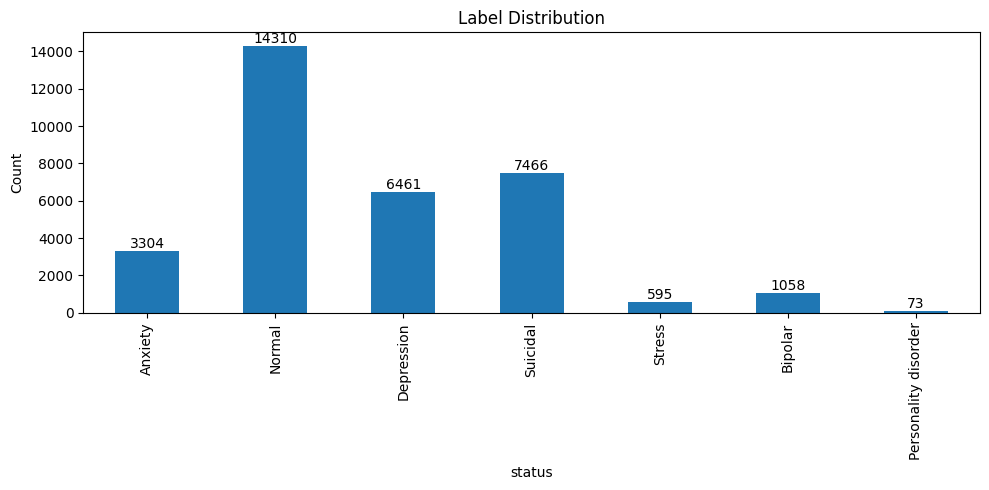

In [13]:
plt.figure(figsize=(10, 5))
counts = df_clean[LABEL_COLUMN].value_counts().reindex(CLASS_NAMES)
ax = counts.plot(kind="bar")
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.title("Label Distribution")
plt.xlabel(LABEL_COLUMN)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 2.3 Master Data Split

In [14]:
groups = df_clean[TEXT_COLUMN]
y = df_clean[LABEL_COLUMN_ENCODED]

# 80/20 → trainval / test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss_test.split(df_clean, y, groups=groups))

split = np.full(len(df_clean), "train", dtype=object)
split[test_idx] = "test"

# 75/25 of trainval → train / val (≈60/20/20)
df_trainval = df_clean.iloc[trainval_idx].copy().reset_index(drop=True)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx2, val_idx = next(
    gss_val.split(df_trainval, df_trainval[LABEL_COLUMN_ENCODED], groups=df_trainval[TEXT_COLUMN])
)
split[trainval_idx[val_idx]] = "val"
df_clean["split"] = split

print("Split counts:")
print(df_clean["split"].value_counts())

# Leakage check
n_leaky = (df_clean.groupby(TEXT_COLUMN)["split"].nunique() > 1).sum()
assert n_leaky == 0, f"{n_leaky} text groups leak across splits!"
print(f"Leakage check passed.")

print("Split proportions:")
print(df_clean["split"].value_counts(normalize=True))

# Save master split
split_path = OUTPUT_PATH / "MentalHealth_master_split.csv"
df_clean.to_csv(split_path, index=False)
print(f"Saved → {split_path}")

Split counts:
split
train    19924
val       6675
test      6668
Name: count, dtype: int64
Leakage check passed.
Split proportions:
split
train    0.598912
val      0.200649
test     0.200439
Name: proportion, dtype: float64
Saved → outputs/03_SameLabel/MentalHealth_master_split.csv


## 2.4 Shared helper functions

### 2.4.1 Bootstrap CI

In [15]:
def bootstrap_f1_ci(y_true, y_pred, n_iterations=1000, average="weighted"):
    """Return the OBSERVED F1 on the full test set plus a bootstrap 95% CI.

    The first element is the direct point estimate, not the mean of the
    bootstrap replicates; replicates are used only for the interval.
    """
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    observed = f1_score(y_true, y_pred, average=average)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(f1_score(y_true[idx], y_pred[idx], average=average))
        except ValueError:
            continue
    if not scores:
        return observed, np.nan, np.nan
    return observed, np.percentile(scores, 2.5), np.percentile(scores, 97.5)


def bootstrap_auc_ci(y_true, y_scores, n_iterations=1000, average="macro"):
    """Observed macro AUC plus a bootstrap 95% CI (point estimate is direct)."""
    y_true, y_scores = np.asarray(y_true), np.asarray(y_scores)
    try:
        observed = roc_auc_score(y_true, y_scores, average=average, multi_class="ovr")
    except Exception:
        observed = np.nan
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(
                roc_auc_score(y_true[idx], y_scores[idx], average=average, multi_class="ovr")
            )
        except ValueError:
            continue
    if not scores:
        return observed, np.nan, np.nan
    return observed, np.percentile(scores, 2.5), np.percentile(scores, 97.5)

### 2.4.2 Plotting

In [16]:
def plot_confusion_matrix(y_true, y_pred, labels, title="Model", save_dir=None):
    """Works for both string labels (ML) and int labels (DL)."""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {title}")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_confusion_matrix.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()


def plot_multiclass_roc(y_true, y_score, classes_list, title="Model", save_dir=None):
    """Works for both string and int class lists."""
    y_true_bin = label_binarize(y_true, classes=classes_list)
    n_classes = len(classes_list)
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    colors = sns.color_palette("mako", n_classes)
    plt.figure(figsize=(10, 8))
    for i, (cls, color) in enumerate(zip(classes_list, colors)):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f"{cls} (AUC={roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title} — Multi-class ROC")
    plt.legend(loc="lower right")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_roc_curve.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()

### 2.4.3 Machine Learning Evaluation Wrapper

In [17]:
def evaluate_ml(model, X_test, y_test, model_name="Model"):
    """Full evaluation for a fitted sklearn classifier."""
    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*50}")

    y_pred = model.predict(X_test)
    classes = model.classes_

    print(classification_report(y_test, y_pred, digits=4, labels=classes))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(y_test, y_pred)
    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

    f1_mac, f1_mac_lo, f1_mac_hi = bootstrap_f1_ci(y_test, y_pred, average="macro")
    print(f"Macro F1:    {f1_mac:.4f}  95% CI [{f1_mac_lo:.4f}, {f1_mac_hi:.4f}]")

    plot_confusion_matrix(y_test, y_pred, labels=classes,
                         title=model_name, save_dir=str(OUTPUT_PATH))

    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(X_test)
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(X_test)
    else:
        print("No probability scores available.")
        return

    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(y_test, y_scores)
    print(f"Macro AUC: {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_multiclass_roc(y_test, y_scores, classes,
                       title=model_name, save_dir=str(OUTPUT_PATH))

### 2.4.4 PyTorch Evaluation Wrapper

In [18]:
@torch.no_grad()
def evaluate_pytorch(model, test_loader, label_encoder, model_name="Model",
                     use_attention_mask=True):
    """Full evaluation for a PyTorch classifier."""
    model.eval().to(DEVICE)
    all_preds, all_probs, all_labels = [], [], []

    for batch in tqdm(test_loader, desc=f"Eval {model_name}"):
        ids = batch["input_ids"].to(DEVICE, non_blocking=True)
        labels = batch["label"].to(DEVICE, non_blocking=True)

        if use_attention_mask:
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids, attention_mask=mask)
        else:
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids)

        logits = outputs.logits if hasattr(outputs, "logits") else outputs
        probs = torch.softmax(logits.float(), dim=1)
        preds = probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    classes_str = label_encoder.classes_
    classes_int = np.arange(NUM_CLASSES)

    print(f"\n{'='*50}")
    print(f"Evaluation: {model_name}")
    print(f"{'='*50}")

    print(classification_report(all_labels, all_preds,
                                target_names=classes_str, digits=4))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(all_labels, all_preds)
    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

    f1_mac, f1_mac_lo, f1_mac_hi = bootstrap_f1_ci(all_labels, all_preds, average="macro")
    print(f"Macro F1:    {f1_mac:.4f}  95% CI [{f1_mac_lo:.4f}, {f1_mac_hi:.4f}]")

    plot_confusion_matrix(all_labels, all_preds, labels=classes_int,
                         title=model_name, save_dir=str(OUTPUT_PATH))

    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(all_labels, all_probs)
    print(f"Macro AUC: {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_multiclass_roc(all_labels, all_probs, classes_int,
                       title=model_name, save_dir=str(OUTPUT_PATH))

    return all_preds, all_probs, all_labels

### 2.4.5 Machine Learning Feature Importance (shared)

In [19]:

def plot_feature_importance(importances, feature_names, model_name="Model", top_n=20):
    """Generic feature importance plot for any ML model."""
    df_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    df_imp["Scaled"] = (df_imp["Importance"] / df_imp["Importance"].max()) * 100
    top = df_imp.sort_values("Importance", ascending=False).head(top_n)

    plt.figure(figsize=(8, 6))
    sns.set_style("whitegrid")
    sns.barplot(x="Scaled", y="Feature", data=top[::-1], palette="mako")
    plt.title(f"Top {top_n} Feature Importance ({model_name})", fontsize=14, fontweight="bold")
    plt.xlabel("Relative Importance (%)")
    plt.ylabel("Feature")
    plt.tight_layout()

    path = OUTPUT_PATH / f"{model_name.lower().replace(' ', '_')}_feature_importance.png"
    plt.savefig(path, dpi=300)
    print(f"Saved → {path}")
    plt.show()

    return top

# 3. Classical ML Modeling

## 3.0 Pre-processing for classical ML Models


In [20]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def ml_preprocess(text: str) -> str:
    if not isinstance(text, str):
        return ""
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words]
    return " ".join(tokens)


df_ml = df_clean.copy()
df_ml["text_ml"] = df_ml[TEXT_COLUMN].apply(ml_preprocess)

df_train_ml = df_ml[df_ml["split"] == "train"].copy()
df_val_ml   = df_ml[df_ml["split"] == "val"].copy()
df_test_ml  = df_ml[df_ml["split"] == "test"].copy()

X_train_ml = df_train_ml["text_ml"].tolist()
X_val_ml   = df_val_ml["text_ml"].tolist()
X_test_ml  = df_test_ml["text_ml"].tolist()

y_train_ml = df_train_ml[LABEL_COLUMN].astype(str).values
y_val_ml   = df_val_ml[LABEL_COLUMN].astype(str).values
y_test_ml  = df_test_ml[LABEL_COLUMN].astype(str).values

# TF-IDF (no stop_words param — already removed in ml_preprocess)
tfidf = TfidfVectorizer(max_features=VOCAB_SIZE)
X_train_tfidf = tfidf.fit_transform(X_train_ml)
X_val_tfidf   = tfidf.transform(X_val_ml)
X_test_tfidf  = tfidf.transform(X_test_ml)

print(f"TF-IDF: train={X_train_tfidf.shape}, val={X_val_tfidf.shape}, test={X_test_tfidf.shape}")
feature_names_tfidf = tfidf.get_feature_names_out()

print(f"ML splits: train={len(df_train_ml)}, val={len(df_val_ml)}, test={len(df_test_ml)}")

TF-IDF: train=(19924, 10000), val=(6675, 10000), test=(6668, 10000)
ML splits: train=19924, val=6675, test=6668


## 3.1 Logistic Regression

### Step 1: Hyperparameter Tuning

In [21]:
RETRAIN = True
if RETRAIN:
    # 7.1 Hyperparameter Tuning (grid search)
    set_seed()
    print("Tuning Logistic Regression...")
    start = time.time()

    lr_grid = {
        "C": [0.1, 1, 10],
        "solver": ["lbfgs", "saga"],
        "class_weight": ["balanced", None],
    }

    best_f1_lr, best_model_lr, best_params_lr = 0, None, None

    for C, solver, cw in product(lr_grid["C"], lr_grid["solver"], lr_grid["class_weight"]):
        try:
            model = LogisticRegression(
                C=C, solver=solver, penalty="l2", multi_class="multinomial",
                class_weight=cw, max_iter=1000, random_state=RANDOM_STATE,
                n_jobs=-1 if solver == "saga" else None,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_lr:
                best_f1_lr = f1
                best_model_lr = model
                best_params_lr = {"C": C, "solver": solver, "class_weight": cw}
                print(f"  LR F1={f1:.4f} | {best_params_lr}")
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"LR tuning: {time.time()-start:.1f}s | Best F1={best_f1_lr:.4f}")

    joblib.dump(best_model_lr, MODEL_PATHS["lr"]["model"])
    with open(MODEL_PATHS["lr"]["params"], "w") as f:
        json.dump(best_params_lr, f, indent=2)
else:
    print("Loading LR from disk...")
    best_model_lr = joblib.load(MODEL_PATHS["lr"]["model"])
    print(f"Loaded LR from {MODEL_PATHS['lr']['model']}")

Tuning Logistic Regression...
  LR F1=0.8635 | {'C': 0.1, 'solver': 'lbfgs', 'class_weight': 'balanced'}
  LR F1=0.8974 | {'C': 1, 'solver': 'lbfgs', 'class_weight': 'balanced'}
  LR F1=0.9039 | {'C': 10, 'solver': 'lbfgs', 'class_weight': 'balanced'}
LR tuning: 150.3s | Best F1=0.9039


### Step 2: Model Evaluation


Evaluation: Logistic_Regression
                      precision    recall  f1-score   support

             Anxiety     0.9363    0.9348    0.9356       629
             Bipolar     0.9534    0.9000    0.9259       250
          Depression     0.8321    0.8527    0.8423      1290
              Normal     0.9538    0.9690    0.9613      2835
Personality disorder     1.0000    0.5333    0.6957        15
              Stress     0.8244    0.8244    0.8244       131
            Suicidal     0.8729    0.8412    0.8568      1518

            accuracy                         0.9078      6668
           macro avg     0.9104    0.8365    0.8631      6668
        weighted avg     0.9077    0.9078    0.9074      6668

Weighted F1: 0.9074  95% CI [0.9005, 0.9140]
Macro F1:    0.8631  95% CI [0.8217, 0.8928]
Saved → outputs/03_SameLabel/Logistic_Regression_confusion_matrix.png


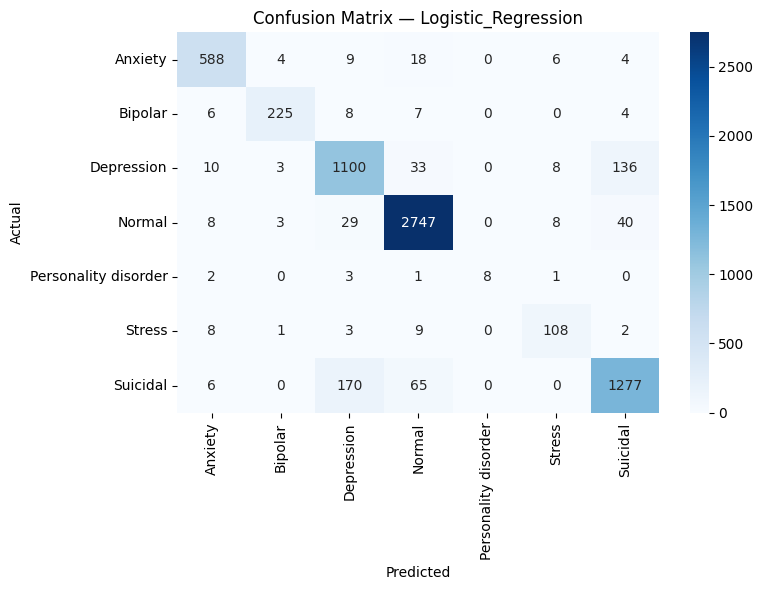

Macro AUC: 0.9894  95% CI [0.9861, 0.9918]
Saved → outputs/03_SameLabel/Logistic_Regression_roc_curve.png


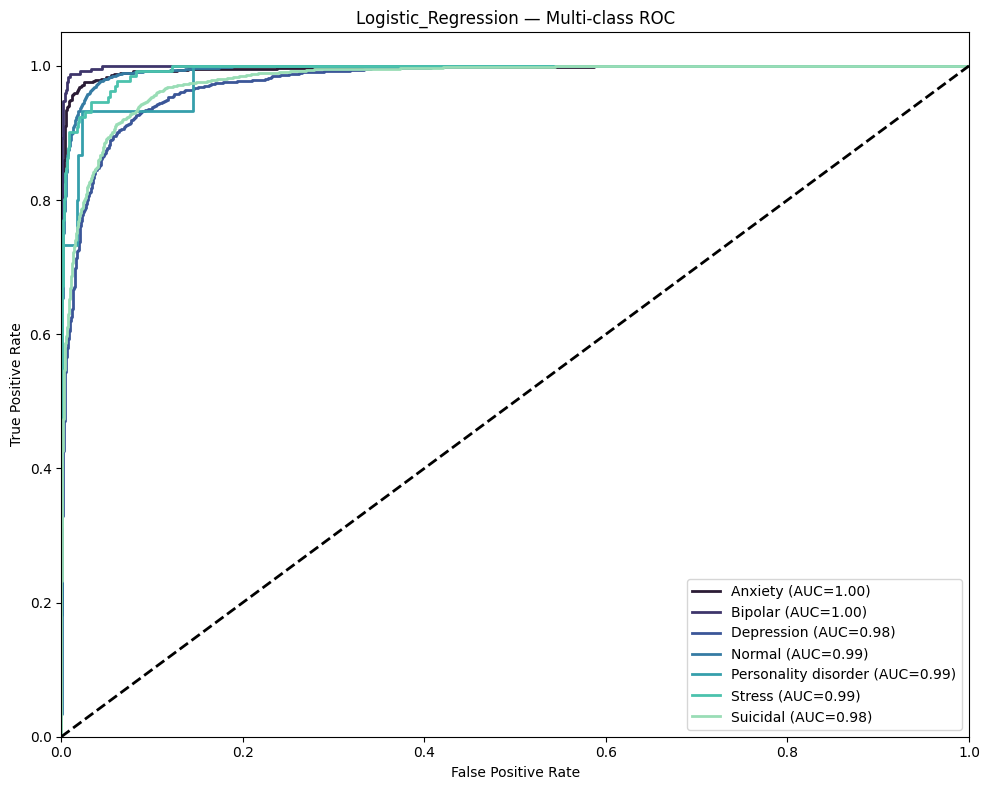

In [22]:
evaluate_ml(best_model_lr, X_test_tfidf, y_test_ml, "Logistic_Regression")

### Step 3: Model Interpretation

Saved → outputs/03_SameLabel/logistic_regression_feature_importance.png


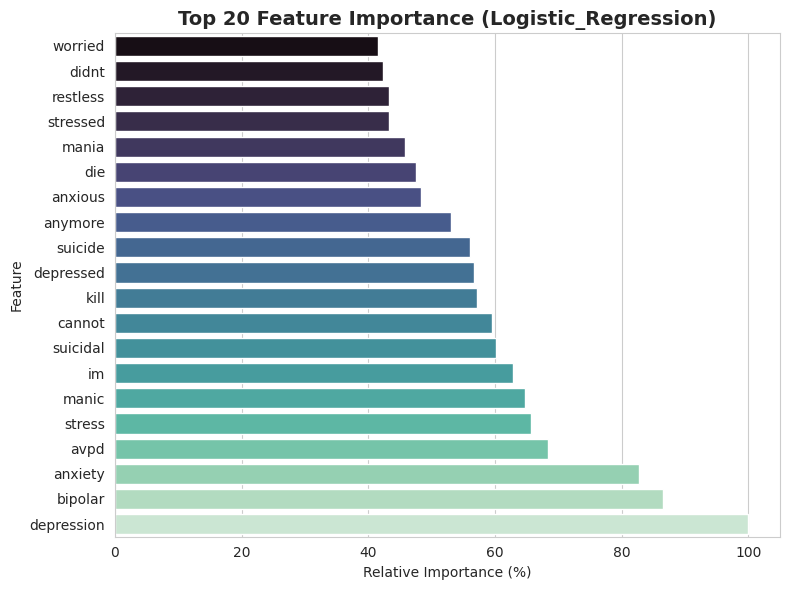

In [23]:
if hasattr(best_model_lr, "coef_"):
    importances_lr = np.abs(best_model_lr.coef_).mean(axis=0) if best_model_lr.coef_.shape[0] > 1 else np.abs(best_model_lr.coef_[0])
    plot_feature_importance(importances_lr, feature_names_tfidf, "Logistic_Regression")

## 3.2 SVM

### Step 1: Hyperparameter Tuning

In [24]:
### Step 1: Hyperparameter Tuning

RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning SVM...")
    start = time.time()

    svm_grid = {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "class_weight": ["balanced", None],
        "gamma": ["scale"],
    }

    best_f1_svm, best_params_svm, best_model_svm = -1.0, None, None

    for C, kernel, class_weight, gamma in product(
        svm_grid["C"], svm_grid["kernel"],
        svm_grid["class_weight"], svm_grid["gamma"]
    ):
        try:
            model = SVC(
                C=C, kernel=kernel, class_weight=class_weight,
                gamma=gamma, random_state=RANDOM_STATE, probability=False,
            )
            model.fit(X_train_tfidf, y_train_ml)
            y_val_pred = model.predict(X_val_tfidf)
            f1 = f1_score(y_val_ml, y_val_pred, average="weighted")

            if f1 > best_f1_svm:
                best_f1_svm = f1
                best_params_svm = {"C": C, "kernel": kernel,
                                   "class_weight": class_weight, "gamma": gamma}
                best_model_svm = model
                print(f"  New best F1: {f1:.4f} | {best_params_svm}")

        except Exception as e:
            print(f"  Skipping: {e}")

    # Retrain best config with probability=True for predict_proba
    print("\nRetraining best SVM with probability=True...")
    best_model_svm = SVC(
        **best_params_svm,
        random_state=RANDOM_STATE, probability=True,
    )
    best_model_svm.fit(X_train_tfidf, y_train_ml)

    elapsed = time.time() - start
    print(f"\nBest SVM: F1={best_f1_svm:.4f} in {elapsed:.1f}s")
    print(f"Params: {best_params_svm}")

    joblib.dump(best_model_svm, MODEL_PATHS["svm"]["model"])
    with open(MODEL_PATHS["svm"]["params"], "w") as f:
        json.dump(best_params_svm, f, indent=2)
    print(f"Saved best SVM model to: {MODEL_PATHS['svm']['model']}")
else:
    best_model_svm = joblib.load(MODEL_PATHS["svm"]["model"])
    with open(MODEL_PATHS["svm"]["params"]) as f:
        best_params_svm = json.load(f)
    print(f"Loaded saved SVM model. Params: {best_params_svm}")


Tuning SVM...
  New best F1: 0.8774 | {'C': 0.1, 'kernel': 'linear', 'class_weight': 'balanced', 'gamma': 'scale'}
  New best F1: 0.9029 | {'C': 1, 'kernel': 'linear', 'class_weight': 'balanced', 'gamma': 'scale'}

Retraining best SVM with probability=True...

Best SVM: F1=0.9029 in 1256.8s
Params: {'C': 1, 'kernel': 'linear', 'class_weight': 'balanced', 'gamma': 'scale'}
Saved best SVM model to: outputs/03_SameLabel/best_svm_model.joblib


### Step 2: Model Evaluation


Evaluation: SVM
                      precision    recall  f1-score   support

             Anxiety     0.9110    0.9444    0.9274       629
             Bipolar     0.9685    0.8600    0.9110       250
          Depression     0.8283    0.8636    0.8455      1290
              Normal     0.9545    0.9683    0.9613      2835
Personality disorder     1.0000    0.3333    0.5000        15
              Stress     0.8174    0.7176    0.7642       131
            Suicidal     0.8851    0.8472    0.8657      1518

            accuracy                         0.9078      6668
           macro avg     0.9092    0.7906    0.8250      6668
        weighted avg     0.9081    0.9078    0.9072      6668

Weighted F1: 0.9072  95% CI [0.8996, 0.9142]
Macro F1:    0.8250  95% CI [0.7795, 0.8616]
Saved → outputs/03_SameLabel/SVM_confusion_matrix.png


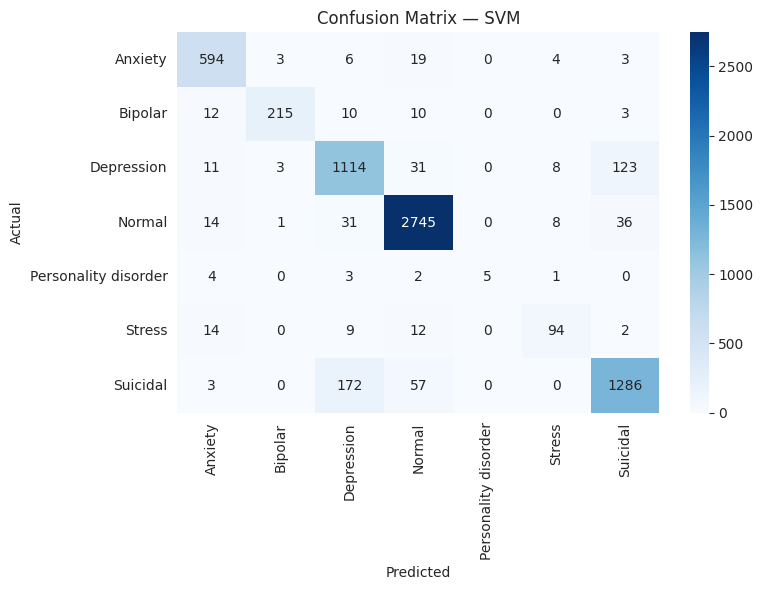

Macro AUC: 0.9883  95% CI [0.9815, 0.9925]
Saved → outputs/03_SameLabel/SVM_roc_curve.png


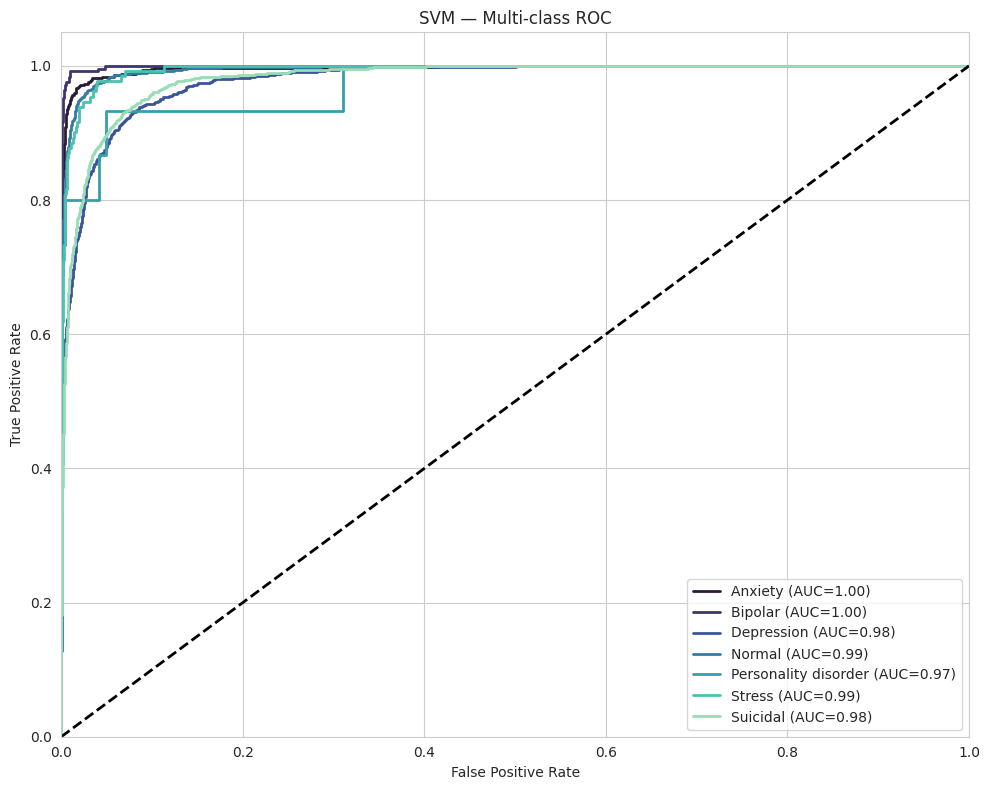

In [25]:
evaluate_ml(best_model_svm, X_test_tfidf, y_test_ml, "SVM")

### Step 3: Model Interpretation

In [26]:
# if best_model_svm.kernel == "linear" and hasattr(best_model_svm, "coef_"):
#     # Linear kernel: use coefficient weights directly (fast)
#     importances_svm = np.abs(best_model_svm.coef_).mean(axis=0)
#     if hasattr(importances_svm, "A1"):  # sparse matrix → flat array
#         importances_svm = importances_svm.A1
#     plot_feature_importance(importances_svm, feature_names_tfidf, "SVM")
# else:
#     # Non-linear kernel: permutation importance (slower)
#     print(f"Kernel='{best_model_svm.kernel}' — using permutation importance...")

#     max_samples = 1000
#     n_val = X_val_tfidf.shape[0]

#     if n_val > max_samples:
#         rng = np.random.RandomState(RANDOM_STATE)
#         idx = rng.choice(n_val, size=max_samples, replace=False)
#         X_perm = X_val_tfidf[idx]
#         y_perm = y_val_ml.iloc[idx] if hasattr(y_val_ml, "iloc") else y_val_ml[idx]
#     else:
#         X_perm = X_val_tfidf
#         y_perm = y_val_ml

#     print(f"Permutation importance on {X_perm.shape[0]} samples...")
#     start = time.time()

#     result = permutation_importance(
#         best_model_svm, X_perm, y_perm,
#         n_repeats=5, random_state=RANDOM_STATE,
#         n_jobs=-1, scoring="f1_weighted",
#     )

#     print(f"Done in {time.time() - start:.1f}s")

#     importances_svm = result.importances_mean.clip(min=0)
#     plot_feature_importance(importances_svm, feature_names_tfidf, "SVM")

## 3.3 Random Forest

### Step 1: Hyperparameter Tuning

In [27]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning Random Forest...")
    start = time.time()

    rf_grid = {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "class_weight": ["balanced", None],
    }

    best_f1_rf, best_model_rf, best_params_rf = 0, None, None

    for n_est, md, mss, msl, cw in tqdm(
        list(product(rf_grid["n_estimators"], rf_grid["max_depth"],
                     rf_grid["min_samples_split"], rf_grid["min_samples_leaf"],
                     rf_grid["class_weight"])),
        desc="RF grid"
    ):
        try:
            model = RandomForestClassifier(
                n_estimators=n_est, max_depth=md, min_samples_split=mss,
                min_samples_leaf=msl, class_weight=cw,
                random_state=RANDOM_STATE, n_jobs=-1,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_rf:
                best_f1_rf = f1
                best_model_rf = model
                best_params_rf = {"n_estimators": n_est, "max_depth": md,
                                  "min_samples_split": mss, "min_samples_leaf": msl,
                                  "class_weight": cw}
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"RF tuning: {time.time()-start:.1f}s | Best F1={best_f1_rf:.4f}")
    print(f"Best params: {best_params_rf}")

    joblib.dump(best_model_rf, MODEL_PATHS["rf"]["model"])
    with open(MODEL_PATHS["rf"]["params"], "w") as f:
        json.dump(best_params_rf, f, indent=2)
else:
    print("Loading RF from disk...")
    best_model_rf = joblib.load(MODEL_PATHS["rf"]["model"])
    print(f"Loaded RF from {MODEL_PATHS['rf']['model']}")


Tuning Random Forest...


RF grid: 100%|██████████| 162/162 [03:44<00:00,  1.38s/it]


RF tuning: 224.1s | Best F1=0.8732
Best params: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 2, 'class_weight': 'balanced'}


### Step 2: Model Evaluation


Evaluation: RandomForest
                      precision    recall  f1-score   support

             Anxiety     0.7944    0.9459    0.8636       629
             Bipolar     0.9539    0.8280    0.8865       250
          Depression     0.8010    0.7798    0.7903      1290
              Normal     0.9514    0.9531    0.9522      2835
Personality disorder     0.0000    0.0000    0.0000        15
              Stress     0.9286    0.4962    0.6468       131
            Suicidal     0.8177    0.8274    0.8225      1518

            accuracy                         0.8745      6668
           macro avg     0.7496    0.6901    0.7088      6668
        weighted avg     0.8746    0.8745    0.8724      6668

Weighted F1: 0.8724  95% CI [0.8646, 0.8804]
Macro F1:    0.7088  95% CI [0.6948, 0.7221]
Saved → outputs/03_SameLabel/RandomForest_confusion_matrix.png


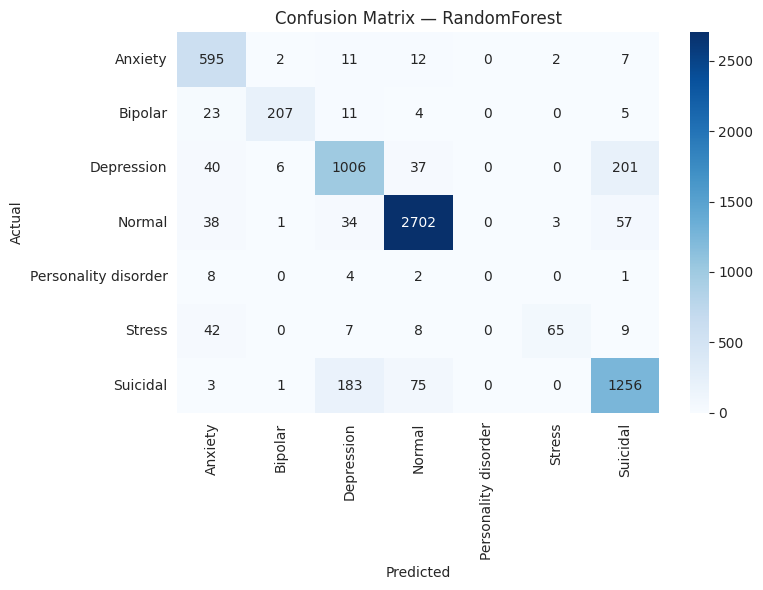

Macro AUC: 0.9810  95% CI [0.9773, 0.9842]
Saved → outputs/03_SameLabel/RandomForest_roc_curve.png


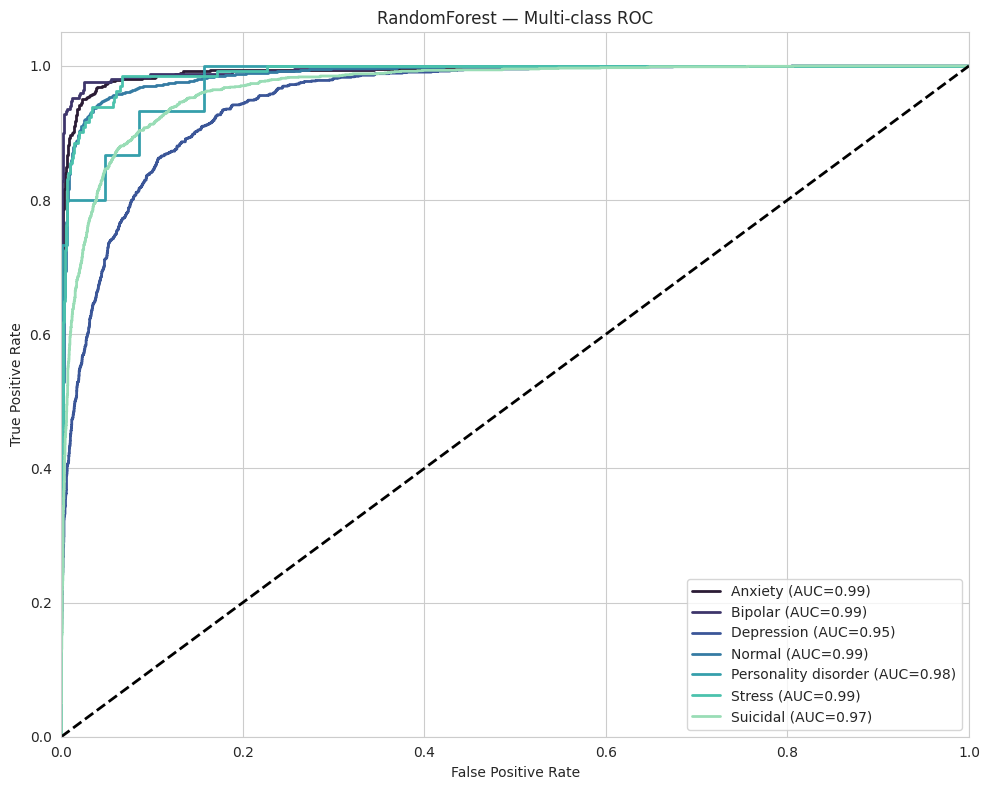

In [28]:
evaluate_ml(best_model_rf, X_test_tfidf, y_test_ml, "RandomForest")

### Step 3: Model Interpretation

Saved → outputs/03_SameLabel/randomforest_feature_importance.png


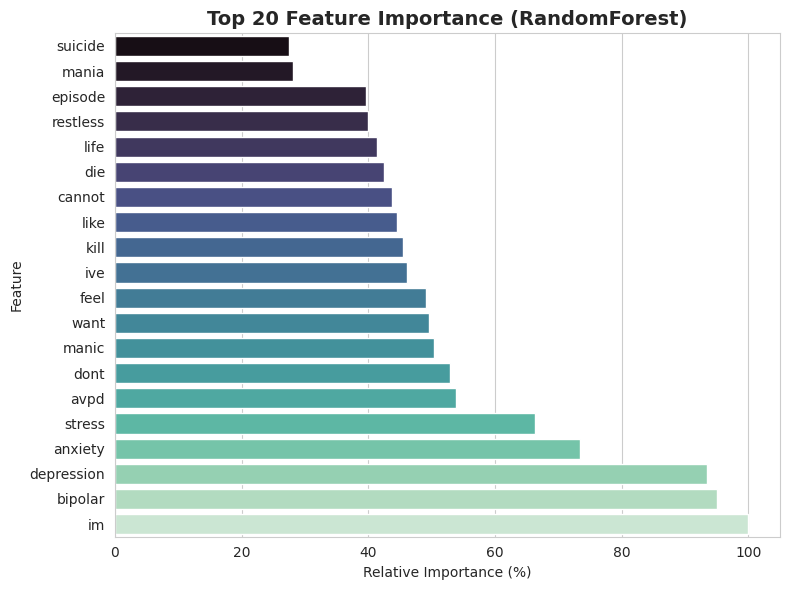

,Feature,Importance,Scaled
4520,im,0.022714,100.000000
1138,bipolar,0.021595,95.074359
2466,depression,0.021233,93.477842
645,anxiety,0.016682,73.441817
8527,stress,0.015064,66.319752
882,avpd,0.012239,53.883420
2790,dont,0.012019,52.913586
5459,manic,0.011449,50.404573
9626,want,0.011261,49.577287
3471,feel,0.011141,49.047528


In [29]:
plot_feature_importance(best_model_rf.feature_importances_, feature_names_tfidf, "RandomForest")

## 3.4 LGBM

### Step 1: Hyperparameter Tuning

In [30]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning LightGBM...")
    start = time.time()

    lgbm_grid = {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "num_leaves": [31, 63],
        "max_depth": [None, 10],
        "class_weight": ["balanced", None],
    }

    best_f1_lgbm, best_model_lgbm, best_params_lgbm = 0, None, None

    for n_est, lr, nl, md, cw in tqdm(
        list(product(lgbm_grid["n_estimators"], lgbm_grid["learning_rate"],
                     lgbm_grid["num_leaves"], lgbm_grid["max_depth"],
                     lgbm_grid["class_weight"])),
        desc="LGBM grid"
    ):
        try:
            model = LGBMClassifier(
                objective="multiclass", n_estimators=n_est, learning_rate=lr,
                num_leaves=nl, max_depth=-1 if md is None else md,
                class_weight=cw, random_state=RANDOM_STATE, n_jobs=-1,
                verbose=-1,
            )
            model.fit(X_train_tfidf, y_train_ml)
            f1 = f1_score(y_val_ml, model.predict(X_val_tfidf), average="weighted")
            if f1 > best_f1_lgbm:
                best_f1_lgbm = f1
                best_model_lgbm = model
                best_params_lgbm = {"n_estimators": n_est, "learning_rate": lr,
                                    "num_leaves": nl, "max_depth": md, "class_weight": cw}
        except Exception as e:
            print(f"  Skipped: {e}")

    print(f"LGBM tuning: {time.time()-start:.1f}s | Best F1={best_f1_lgbm:.4f}")
    print(f"Best params: {best_params_lgbm}")

    joblib.dump(best_model_lgbm, MODEL_PATHS["lgbm"]["model"])
    with open(MODEL_PATHS["lgbm"]["params"], "w") as f:
        json.dump(best_params_lgbm, f, indent=2)
else:
    print("Loading LGBM from disk...")
    best_model_lgbm = joblib.load(MODEL_PATHS["lgbm"]["model"])
    print(f"Loaded LGBM from {MODEL_PATHS['lgbm']['model']}")



Tuning LightGBM...


LGBM grid: 100%|██████████| 48/48 [21:55<00:00, 27.41s/it]


LGBM tuning: 1315.7s | Best F1=0.9166
Best params: {'n_estimators': 200, 'learning_rate': 0.1, 'num_leaves': 31, 'max_depth': None, 'class_weight': 'balanced'}


### Step 2: Model Evaluation


Evaluation: LightGBM
                      precision    recall  f1-score   support

             Anxiety     0.9176    0.9380    0.9277       629
             Bipolar     0.9512    0.9360    0.9435       250
          Depression     0.8453    0.8643    0.8547      1290
              Normal     0.9604    0.9743    0.9673      2835
Personality disorder     0.9000    0.6000    0.7200        15
              Stress     0.8812    0.6794    0.7672       131
            Suicidal     0.8900    0.8636    0.8766      1518

            accuracy                         0.9163      6668
           macro avg     0.9065    0.8365    0.8653      6668
        weighted avg     0.9160    0.9163    0.9157      6668

Weighted F1: 0.9157  95% CI [0.9090, 0.9221]
Macro F1:    0.8653  95% CI [0.8233, 0.8929]
Saved → outputs/03_SameLabel/LightGBM_confusion_matrix.png


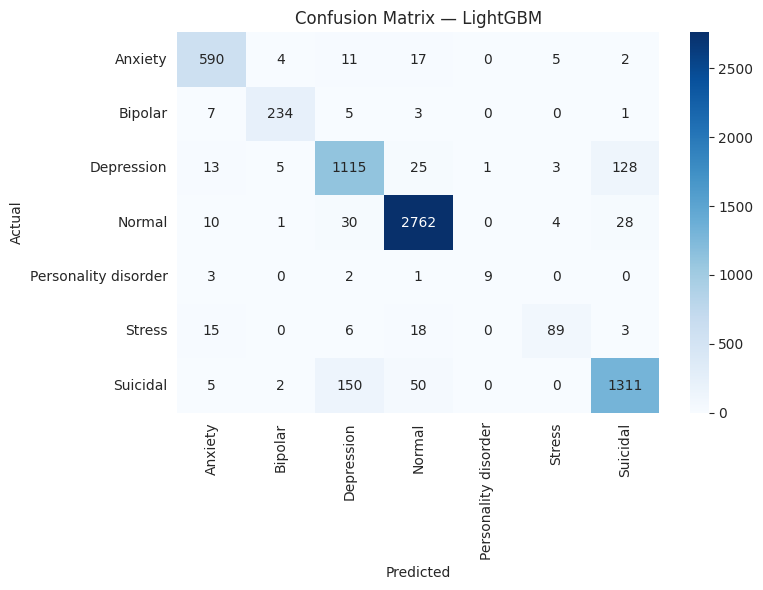

Macro AUC: 0.9893  95% CI [0.9855, 0.9921]
Saved → outputs/03_SameLabel/LightGBM_roc_curve.png


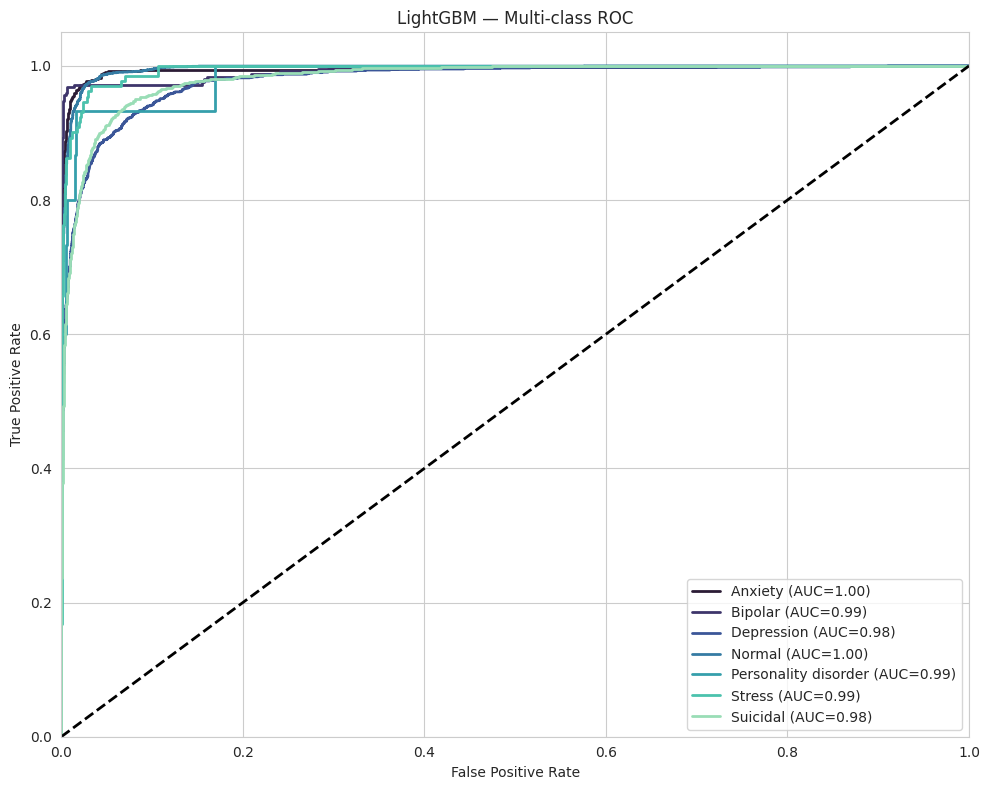

In [31]:
evaluate_ml(best_model_lgbm, X_test_tfidf, y_test_ml, "LightGBM")

### Step 3: Model Interpretation

Saved → outputs/03_SameLabel/lightgbm_feature_importance.png


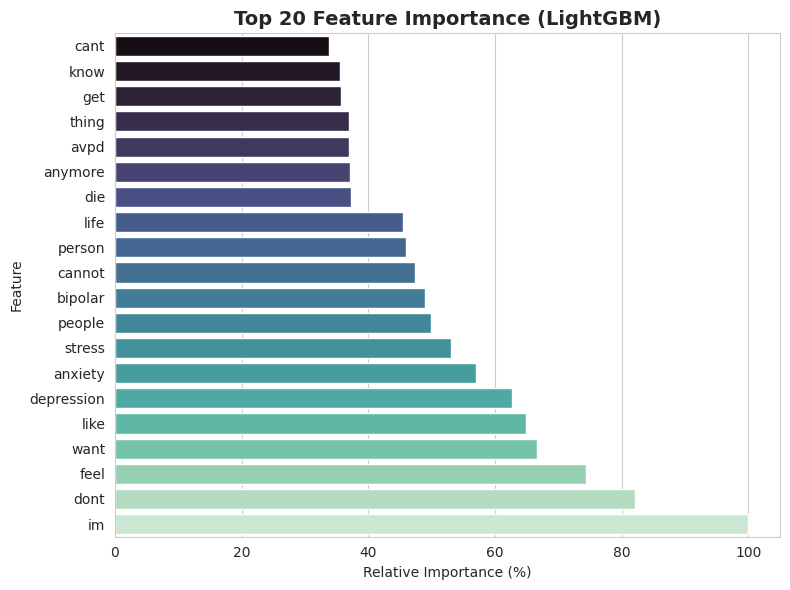

,Feature,Importance,Scaled
4520,im,628,100.000000
2790,dont,516,82.165605
3471,feel,467,74.363057
9626,want,418,66.560510
5243,like,408,64.968153
2466,depression,394,62.738854
645,anxiety,358,57.006369
8527,stress,333,53.025478
6496,people,313,49.840764
1138,bipolar,307,48.885350


In [32]:
plot_feature_importance(best_model_lgbm.feature_importances_, feature_names_tfidf, "LightGBM")

## 3.4 Save Predictions for Machine Learning Models

In [33]:
print("\nSaving ML predictions...")

y_true_str = df_test_ml[LABEL_COLUMN].astype(str).values
y_true_id  = label_encoder.transform(y_true_str)

lr_pred   = best_model_lr.predict(X_test_tfidf)
svm_pred  = best_model_svm.predict(X_test_tfidf)
rf_pred   = best_model_rf.predict(X_test_tfidf)
lgbm_pred = best_model_lgbm.predict(X_test_tfidf)

lr_proba   = best_model_lr.predict_proba(X_test_tfidf)
svm_proba  = best_model_svm.predict_proba(X_test_tfidf)
rf_proba   = best_model_rf.predict_proba(X_test_tfidf)
lgbm_proba = best_model_lgbm.predict_proba(X_test_tfidf)

class_names_ml = best_model_lr.classes_
assert np.array_equal(class_names_ml, best_model_svm.classes_)
assert np.array_equal(class_names_ml, best_model_rf.classes_)
assert np.array_equal(class_names_ml, best_model_lgbm.classes_)

# Build prediction DataFrame
if "id" in df_test_ml.columns:
    df_pred_ml = df_test_ml[["id", TEXT_COLUMN]].copy()
else:
    df_pred_ml = df_test_ml[[TEXT_COLUMN]].copy()
    df_pred_ml.insert(0, "id", df_test_ml.index)

df_pred_ml["true_label"]    = y_true_str
df_pred_ml["true_label_id"] = y_true_id
df_pred_ml["lr_pred"]       = lr_pred
df_pred_ml["svm_pred"]      = svm_pred
df_pred_ml["rf_pred"]       = rf_pred
df_pred_ml["lgbm_pred"]     = lgbm_pred

for i, cls in enumerate(class_names_ml):
    df_pred_ml[f"lr_prob_{cls}"]   = lr_proba[:, i]
    df_pred_ml[f"svm_prob_{cls}"]  = svm_proba[:, i]
    df_pred_ml[f"rf_prob_{cls}"]   = rf_proba[:, i]
    df_pred_ml[f"lgbm_prob_{cls}"] = lgbm_proba[:, i]

ml_pred_path = OUTPUT_PATH / "ml_models_predictions.csv"
df_pred_ml.to_csv(ml_pred_path, index=False)
print(f"Saved ML predictions → {ml_pred_path}")


Saving ML predictions...
Saved ML predictions → outputs/03_SameLabel/ml_models_predictions.csv


# 4. DL Models


## 4.0 Pre-processing \& data preparation for DL Models

In [ ]:
df_train_dl = df_clean[df_clean["split"] == "train"].copy()
df_val_dl   = df_clean[df_clean["split"] == "val"].copy()
df_test_dl  = df_clean[df_clean["split"] == "test"].copy()

train_labels_dl = df_train_dl[LABEL_COLUMN_ENCODED].tolist()
val_labels_dl   = df_val_dl[LABEL_COLUMN_ENCODED].tolist()
test_labels_dl  = df_test_dl[LABEL_COLUMN_ENCODED].tolist()

# ── GRU/CNN and Transformers all use augmented text (model_text) ──
train_texts_dl = df_train_dl[TEXT_COLUMN].fillna("").astype(str).tolist()
val_texts_dl   = df_val_dl[TEXT_COLUMN].fillna("").astype(str).tolist()
test_texts_dl  = df_test_dl[TEXT_COLUMN].fillna("").astype(str).tolist()

print(f"DL splits: train={len(train_texts_dl)}, val={len(val_texts_dl)}, test={len(test_texts_dl)}")

# ── Build shared vocabulary (GRU + CNN — from raw text) ──
# PAD=0, UNK=1, words start at 2
vocab_counter = Counter()
for text in train_texts_dl:
    vocab_counter.update(text.split())
most_common = [w for w, _ in vocab_counter.most_common(VOCAB_SIZE - 2)]  # -2 for PAD and UNK
word_to_index = {w: i + 2 for i, w in enumerate(most_common)}  # 0=PAD, 1=UNK
UNK_IDX = 1

print(f"Vocabulary: {len(word_to_index)} words + PAD(0) + UNK(1)")


def text_to_sequence(text, w2i, max_len=MAX_TOKEN_LENGTH):
    tokens = text.split()
    return [w2i.get(w, UNK_IDX) for w in tokens][:max_len]


# ── Convert & pad sequences (fixed length = MAX_TOKEN_LENGTH) ──
def build_padded_sequences(texts, w2i, max_len=MAX_TOKEN_LENGTH):
    seqs = []
    for t in texts:
        seq = text_to_sequence(t, w2i, max_len)
        # Pad to exactly max_len (not max-in-split)
        padded = seq + [0] * (max_len - len(seq))
        seqs.append(padded)
    return torch.tensor(seqs, dtype=torch.long)

train_seqs = build_padded_sequences(train_texts_dl, word_to_index)
val_seqs   = build_padded_sequences(val_texts_dl, word_to_index)
test_seqs  = build_padded_sequences(test_texts_dl, word_to_index)

train_labels_t = torch.tensor(train_labels_dl, dtype=torch.long)
val_labels_t   = torch.tensor(val_labels_dl, dtype=torch.long)
test_labels_t  = torch.tensor(test_labels_dl, dtype=torch.long)

print(f"Sequence shapes: train={train_seqs.shape}, val={val_seqs.shape}, test={test_seqs.shape}")

DL splits: train=19924, val=6675, test=6668
Vocabulary: 9998 words + PAD(0) + UNK(1)
Sequence shapes: train=torch.Size([19924, 200]), val=torch.Size([6675, 200]), test=torch.Size([6668, 200])


In [ ]:
# ── Dataset class (GRU + CNN) ────────────────────────────
class SeqDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {"input_ids": self.sequences[idx], "label": self.labels[idx]}


# ── DataLoaders (shared, with pin_memory) ────────────────
_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2,
                  pin_memory=True, persistent_workers=True)

train_loader_seq = DataLoader(SeqDataset(train_seqs, train_labels_t), shuffle=True, **_loader_kw)
val_loader_seq   = DataLoader(SeqDataset(val_seqs, val_labels_t), shuffle=False, **_loader_kw)
test_loader_seq  = DataLoader(SeqDataset(test_seqs, test_labels_t), shuffle=False, **_loader_kw)

# ── Class weights for DL training ────────────────────────
_cw = compute_class_weight("balanced", classes=np.unique(train_labels_dl), y=train_labels_dl)
class_weights_dl = torch.tensor(_cw, dtype=torch.float32).to(DEVICE)

## 4.1 Neural Network (GRU \& CNN)

### 4.1.1 Generic train + evaluation

In [ ]:
def train_seq_model(model, train_loader, val_loader, lr=1e-3,
                    max_epochs=20, patience=5):
    """Train a sequence model (GRU or CNN) with early stopping."""
    model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights_dl)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scaler = GradScaler(enabled=USE_FP16)

    best_f1, best_state, no_improve = -1.0, None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            ids = batch["input_ids"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda", enabled=USE_FP16):
                logits = model(ids)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), SEQ_MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            losses.append(loss.item())

        # Validate
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids = batch["input_ids"].to(DEVICE, non_blocking=True)
                labels = batch["label"]
                with autocast("cuda", enabled=USE_FP16):
                    logits = model(ids)
                val_preds.extend(logits.float().argmax(dim=1).cpu().numpy())
                val_true.extend(labels.numpy())

        val_f1 = f1_score(val_true, val_preds, average="weighted")
        val_acc = accuracy_score(val_true, val_preds)
        print(f"  Epoch {epoch}/{max_epochs} | Loss={np.mean(losses):.4f} | "
              f"Val F1={val_f1:.4f} | Val Acc={val_acc:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    if best_state:
        model.load_state_dict(best_state)
    return best_f1, model

### 4.1.2 GRU

#### Step 1: Define GRU Model

In [ ]:
class GRUSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.gru = nn.GRU(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        embedded = self.embedding(input_ids)
        _, hidden = self.gru(embedded)
        return self.fc(self.dropout(hidden[-1]))

#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True
if RETRAIN:
    set_seed()
    print("\nTuning GRU...")
    start = time.time()

    MAX_EPOCHS_GRU = 20
    PATIENCE_GRU = 5

    gru_param_space = {
        "embedding_dim": (150, 300),
        "hidden_dim": (128, 384),
        "lr": (np.log10(1e-4), np.log10(1e-3)),  # log-uniform
    }

    best_f1_gru, best_params_gru, best_gru = -1.0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="GRU Random Search"):
        hp = {
            "embedding_dim": int(np.random.uniform(*gru_param_space["embedding_dim"])),
            "hidden_dim": int(np.random.uniform(*gru_param_space["hidden_dim"])),
            "lr": float(10 ** np.random.uniform(*gru_param_space["lr"])),
        }

        model = GRUSentimentModel(
            vocab_size=VOCAB_SIZE, embedding_dim=hp["embedding_dim"],
            hidden_dim=hp["hidden_dim"], output_dim=NUM_CLASSES,
        )

        f1_val, model = train_seq_model(
            model, train_loader_seq, val_loader_seq,
            lr=hp["lr"], max_epochs=MAX_EPOCHS_GRU, patience=PATIENCE_GRU,
        )

        if f1_val > best_f1_gru:
            best_f1_gru = f1_val
            best_params_gru = hp
            best_gru = model

    print(f"GRU tuning: {time.time()-start:.1f}s | Best F1={best_f1_gru:.4f}")
    print(f"Best params: {best_params_gru}")

    torch.save(best_gru.state_dict(), MODEL_PATHS["gru"]["model"])
    with open(MODEL_PATHS["gru"]["params"], "w") as f:
        json.dump(best_params_gru, f, indent=2)
else:
    print("Loading GRU from disk...")
    with open(MODEL_PATHS["gru"]["params"]) as f:
        best_params_gru = json.load(f)
    best_gru = GRUSentimentModel(
        vocab_size=VOCAB_SIZE, embedding_dim=int(best_params_gru["embedding_dim"]),
        hidden_dim=int(best_params_gru["hidden_dim"]), output_dim=NUM_CLASSES,
    )
    best_gru.load_state_dict(torch.load(MODEL_PATHS["gru"]["model"], map_location=DEVICE))
    print(f"Loaded GRU from {MODEL_PATHS['gru']['model']}")



Tuning GRU...


GRU Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1/20 | Loss=1.9017 | Val F1=0.3663 | Val Acc=0.4790
  Epoch 2/20 | Loss=1.8028 | Val F1=0.3742 | Val Acc=0.4858
  Epoch 3/20 | Loss=1.5170 | Val F1=0.2720 | Val Acc=0.2804
  Epoch 4/20 | Loss=1.1496 | Val F1=0.6721 | Val Acc=0.6632
  Epoch 5/20 | Loss=0.9026 | Val F1=0.7437 | Val Acc=0.7206
  Epoch 6/20 | Loss=0.6371 | Val F1=0.8161 | Val Acc=0.8024
  Epoch 7/20 | Loss=0.4384 | Val F1=0.8360 | Val Acc=0.8328
  Epoch 8/20 | Loss=0.2877 | Val F1=0.8553 | Val Acc=0.8508


#### Step 3: Model Evaluation

Eval GRU: 100%|██████████| 53/53 [00:00<00:00, 164.38it/s]



Evaluation: GRU
                      precision    recall  f1-score   support

             Anxiety     0.8785    0.9078    0.8929       629
              Normal     0.9614    0.9573    0.9593      2835
          Depression     0.7621    0.8442    0.8010      1290
            Suicidal     0.8698    0.8057    0.8365      1518
              Stress     0.5354    0.5191    0.5271       131
             Bipolar     0.9414    0.8360    0.8856       250
Personality disorder     0.2727    0.2000    0.2308        15

            accuracy                         0.8814      6668
           macro avg     0.7459    0.7243    0.7333      6668
        weighted avg     0.8835    0.8814    0.8816      6668

Weighted F1: 0.8816  95% CI [0.8742, 0.8896]
Macro F1:    0.7333  95% CI [0.6972, 0.7666]
Saved → outputs/03_SameLabel/GRU_confusion_matrix.png


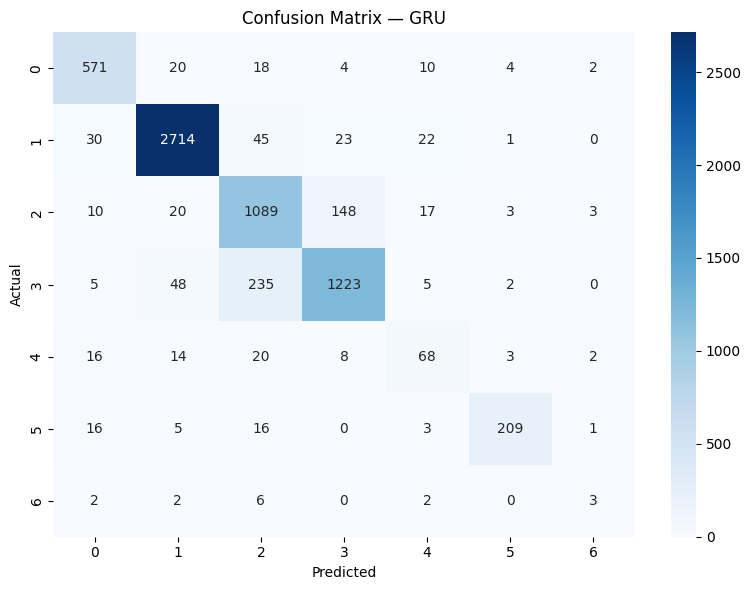

Macro AUC: 0.9716  95% CI [0.9647, 0.9779]
Saved → outputs/03_SameLabel/GRU_roc_curve.png


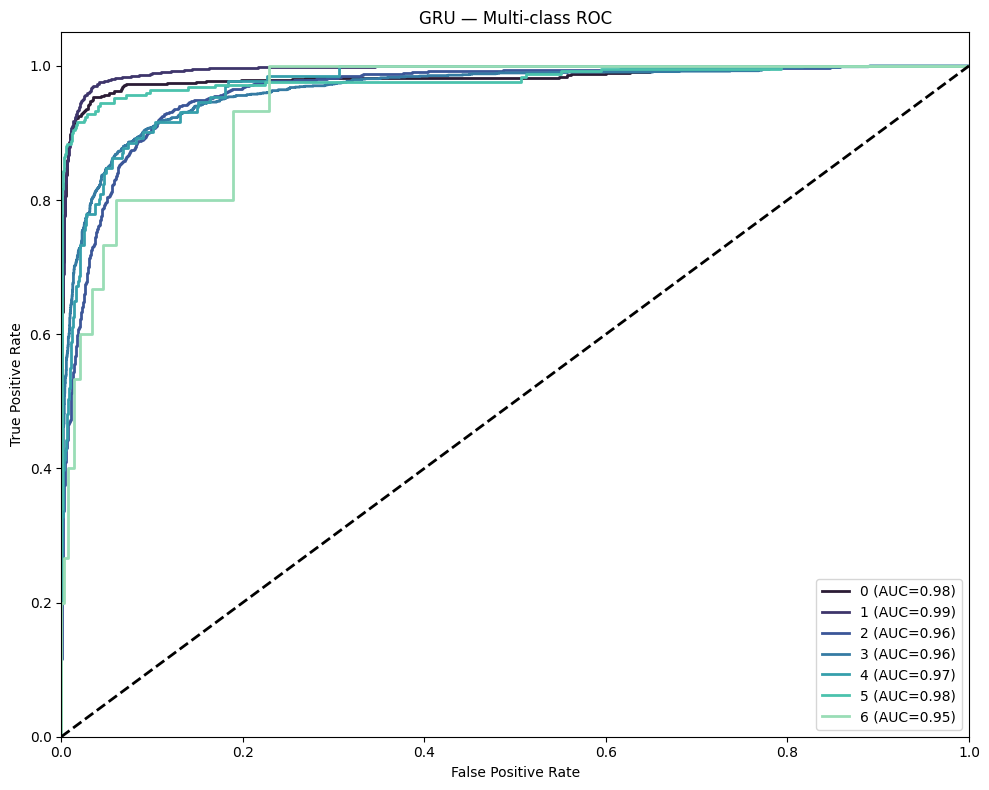

In [ ]:
gru_preds, gru_probs, y_true_gru = evaluate_pytorch(
    best_gru, test_loader_seq, label_encoder, "GRU", use_attention_mask=False
)

### 4.1.3 CNN

### 4.2.2 CNN Modeling

#### Step 1: Define CNN Model

In [ ]:
class CNNSentimentModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_filters, filter_sizes,
                 output_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embedding_dim, num_filters, fs) for fs in filter_sizes
        ])
        self.fc = nn.Linear(num_filters * len(filter_sizes), output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        x = self.embedding(input_ids).permute(0, 2, 1)  # [B, E, L]
        pooled = [torch.relu(conv(x)).max(dim=2).values for conv in self.convs]
        cat = torch.cat(pooled, dim=1)
        return self.fc(self.dropout(cat))

#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

FILTER_SIZES = [3, 4, 5]

if RETRAIN:
    set_seed()
    print("\nTuning CNN...")
    start = time.time()

    MAX_EPOCHS_CNN = 20
    PATIENCE_CNN = 5

    cnn_param_space = {
        "embedding_dim": (150, 300),     # uniform
        "num_filters":  (80, 200),       # filters per kernel size
        "lr": (np.log10(1e-4), np.log10(1e-3)),  # log-uniform
    }

    best_f1_cnn, best_params_cnn, best_cnn = -1.0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="CNN Random Search"):
        hp = {
            "embedding_dim": int(np.random.uniform(*cnn_param_space["embedding_dim"])),
            "num_filters": int(np.random.uniform(*cnn_param_space["num_filters"])),
            "lr": float(10 ** np.random.uniform(*cnn_param_space["lr"])),
        }

        model = CNNSentimentModel(
            vocab_size=VOCAB_SIZE, embedding_dim=hp["embedding_dim"],
            num_filters=hp["num_filters"], filter_sizes=FILTER_SIZES,
            output_dim=NUM_CLASSES,
        )

        f1_val, model = train_seq_model(
            model, train_loader_seq, val_loader_seq,
            lr=hp["lr"], max_epochs=MAX_EPOCHS_CNN, patience=PATIENCE_CNN,
        )

        if f1_val > best_f1_cnn:
            best_f1_cnn = f1_val
            best_params_cnn = hp
            best_cnn = model

    print(f"CNN tuning: {time.time()-start:.1f}s | Best F1={best_f1_cnn:.4f}")
    print(f"Best params: {best_params_cnn}")

    torch.save(best_cnn.state_dict(), MODEL_PATHS["cnn"]["model"])
    with open(MODEL_PATHS["cnn"]["params"], "w") as f:
        json.dump(best_params_cnn, f, indent=2)
else:
    print("Loading CNN from disk...")
    with open(MODEL_PATHS["cnn"]["params"]) as f:
        best_params_cnn = json.load(f)
    best_cnn = CNNSentimentModel(
        vocab_size=VOCAB_SIZE, embedding_dim=int(best_params_cnn["embedding_dim"]),
        num_filters=int(best_params_cnn["num_filters"]), filter_sizes=FILTER_SIZES,
        output_dim=NUM_CLASSES,
    )
    best_cnn.load_state_dict(torch.load(MODEL_PATHS["cnn"]["model"], map_location=DEVICE))
    print(f"Loaded CNN from {MODEL_PATHS['cnn']['model']}")


Tuning CNN...


CNN Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

  Epoch 1/20 | Loss=1.4342 | Val F1=0.7929 | Val Acc=0.7811
  Epoch 2/20 | Loss=0.6374 | Val F1=0.8606 | Val Acc=0.8617
  Epoch 3/20 | Loss=0.4039 | Val F1=0.8727 | Val Acc=0.8740
  Epoch 4/20 | Loss=0.2571 | Val F1=0.8890 | Val Acc=0.8884
  Epoch 5/20 | Loss=0.2143 | Val F1=0.8898 | Val Acc=0.8876
  Epoch 6/20 | Loss=0.1688 | Val F1=0.8884 | Val Acc=0.8878
  Epoch 7/20 | Loss=0.1468 | Val F1=0.8920 | Val Acc=0.8923
  Epoch 8/20 | Loss=0.1267 | Val F1=0.8974 | Val Acc=0.8947
  Epoch 9/20 | Loss=0.1074 | Val F1=0.8998 | Val Acc=0.9013
  Epoch 10/20 | Loss=0.0820 | Val F1=0.9005 | Val Acc=0.9007
  Epoch 11/20 | Loss=0.0812 | Val F1=0.8982 | Val Acc=0.8998
  Epoch 12/20 | Loss=0.0682 | Val F1=0.8827 | Val Acc=0.8837
  Epoch 13/20 | Loss=0.0642 | Val F1=0.9049 | Val Acc=0.9050
  Epoch 14/20 | Loss=0.0550 | Val F1=0.9023 | Val Acc=0.9026
  Epoch 15/20 | Loss=0.0422 | Val F1=0.8972 | Val Acc=0.8980
  Epoch 16/20 | Loss=0.0405 | Val F1=0.9030 | Val Acc=0.9023
  Epoch 17/20 | Loss=0.0341 | Val

CNN Random Search:  10%|█         | 1/10 [00:17<02:33, 17.01s/it]

  Epoch 18/20 | Loss=0.0400 | Val F1=0.8972 | Val Acc=0.8983
  Early stopping at epoch 18.
  Epoch 1/20 | Loss=1.8538 | Val F1=0.6628 | Val Acc=0.6451
  Epoch 2/20 | Loss=1.2904 | Val F1=0.7643 | Val Acc=0.7551
  Epoch 3/20 | Loss=0.9465 | Val F1=0.7957 | Val Acc=0.7924
  Epoch 4/20 | Loss=0.7364 | Val F1=0.8169 | Val Acc=0.8166
  Epoch 5/20 | Loss=0.5935 | Val F1=0.8283 | Val Acc=0.8280
  Epoch 6/20 | Loss=0.5007 | Val F1=0.8468 | Val Acc=0.8466
  Epoch 7/20 | Loss=0.4212 | Val F1=0.8558 | Val Acc=0.8547
  Epoch 8/20 | Loss=0.3685 | Val F1=0.8669 | Val Acc=0.8658
  Epoch 9/20 | Loss=0.3338 | Val F1=0.8713 | Val Acc=0.8691
  Epoch 10/20 | Loss=0.2978 | Val F1=0.8781 | Val Acc=0.8776
  Epoch 11/20 | Loss=0.2731 | Val F1=0.8821 | Val Acc=0.8818
  Epoch 12/20 | Loss=0.2472 | Val F1=0.8828 | Val Acc=0.8821
  Epoch 13/20 | Loss=0.2251 | Val F1=0.8840 | Val Acc=0.8837
  Epoch 14/20 | Loss=0.2061 | Val F1=0.8867 | Val Acc=0.8875
  Epoch 15/20 | Loss=0.1928 | Val F1=0.8836 | Val Acc=0.8834
  E

...

  Epoch 20/20 | Loss=0.1331 | Val F1=0.8937 | Val Acc=0.8938
  Epoch 1/20 | Loss=1.7299 | Val F1=0.7007 | Val Acc=0.6824
  Epoch 2/20 | Loss=1.0133 | Val F1=0.7913 | Val Acc=0.7861
  Epoch 3/20 | Loss=0.6707 | Val F1=0.8308 | Val Acc=0.8286
  Epoch 4/20 | Loss=0.4935 | Val F1=0.8523 | Val Acc=0.8484
  Epoch 5/20 | Loss=0.3758 | Val F1=0.8668 | Val Acc=0.8650
  Epoch 6/20 | Loss=0.3081 | Val F1=0.8767 | Val Acc=0.8773
  Epoch 7/20 | Loss=0.2604 | Val F1=0.8794 | Val Acc=0.8773
  Epoch 8/20 | Loss=0.2341 | Val F1=0.8869 | Val Acc=0.8860
  Epoch 9/20 | Loss=0.1988 | Val F1=0.8886 | Val Acc=0.8890
  Epoch 10/20 | Loss=0.1744 | Val F1=0.8912 | Val Acc=0.8914
  Epoch 11/20 | Loss=0.1539 | Val F1=0.8929 | Val Acc=0.8930
  Epoch 12/20 | Loss=0.1404 | Val F1=0.8895 | Val Acc=0.8897
  Epoch 13/20 | Loss=0.1305 | Val F1=0.8973 | Val Acc=0.8974
  Epoch 14/20 | Loss=0.1173 | Val F1=0.8982 | Val Acc=0.8989
  Epoch 15/20 | Loss=0.1064 | Val F1=0.8981 | Val Acc=0.8989
  Epoch 16/20 | Loss=0.0983 | Val

CNN Random Search:  90%|█████████ | 9/10 [02:40<00:18, 18.17s/it]

  Epoch 20/20 | Loss=0.0711 | Val F1=0.9020 | Val Acc=0.9029
  Epoch 1/20 | Loss=1.9299 | Val F1=0.5779 | Val Acc=0.5402
  Epoch 2/20 | Loss=1.5556 | Val F1=0.6722 | Val Acc=0.6551
  Epoch 3/20 | Loss=1.2975 | Val F1=0.7293 | Val Acc=0.7224
  Epoch 4/20 | Loss=1.1003 | Val F1=0.7713 | Val Acc=0.7697
  Epoch 5/20 | Loss=0.9477 | Val F1=0.7878 | Val Acc=0.7841
  Epoch 6/20 | Loss=0.8091 | Val F1=0.8012 | Val Acc=0.8012
  Epoch 7/20 | Loss=0.7084 | Val F1=0.8166 | Val Acc=0.8150
  Epoch 8/20 | Loss=0.6471 | Val F1=0.8239 | Val Acc=0.8229
  Epoch 9/20 | Loss=0.5901 | Val F1=0.8311 | Val Acc=0.8309
  Epoch 10/20 | Loss=0.5248 | Val F1=0.8316 | Val Acc=0.8304
  Epoch 11/20 | Loss=0.4944 | Val F1=0.8417 | Val Acc=0.8400
  Epoch 12/20 | Loss=0.4478 | Val F1=0.8510 | Val Acc=0.8511
  Epoch 13/20 | Loss=0.4188 | Val F1=0.8563 | Val Acc=0.8566
  Epoch 14/20 | Loss=0.3899 | Val F1=0.8560 | Val Acc=0.8565
  Epoch 15/20 | Loss=0.3623 | Val F1=0.8600 | Val Acc=0.8602
  Epoch 16/20 | Loss=0.3424 | Val

CNN Random Search: 100%|██████████| 10/10 [02:58<00:00, 17.85s/it]

  Epoch 20/20 | Loss=0.2868 | Val F1=0.8698 | Val Acc=0.8701
CNN tuning: 178.5s | Best F1=0.9066
Best params: {'embedding_dim': 193, 'num_filters': 153, 'lr': 0.0008185164112182907}


#### Step 3: Model Evaluation

Eval CNN: 100%|██████████| 53/53 [00:00<00:00, 369.78it/s]


Evaluation: CNN
                      precision    recall  f1-score   support

             Anxiety     0.9104    0.9205    0.9154       629
              Normal     0.9657    0.9732    0.9694      2835
          Depression     0.8505    0.8248    0.8375      1290
            Suicidal     0.8681    0.8715    0.8698      1518
              Stress     0.7025    0.8473    0.7682       131
             Bipolar     0.9526    0.8840    0.9170       250
Personality disorder     0.9000    0.6000    0.7200        15

            accuracy                         0.9097      6668
           macro avg     0.8785    0.8459    0.8568      6668
        weighted avg     0.9102    0.9097    0.9096      6668



Weighted F1: 0.9096  95% CI [0.9027, 0.9162]
Macro F1:    0.8568  95% CI [0.8195, 0.8831]
Saved → outputs/03_SameLabel/CNN_confusion_matrix.png


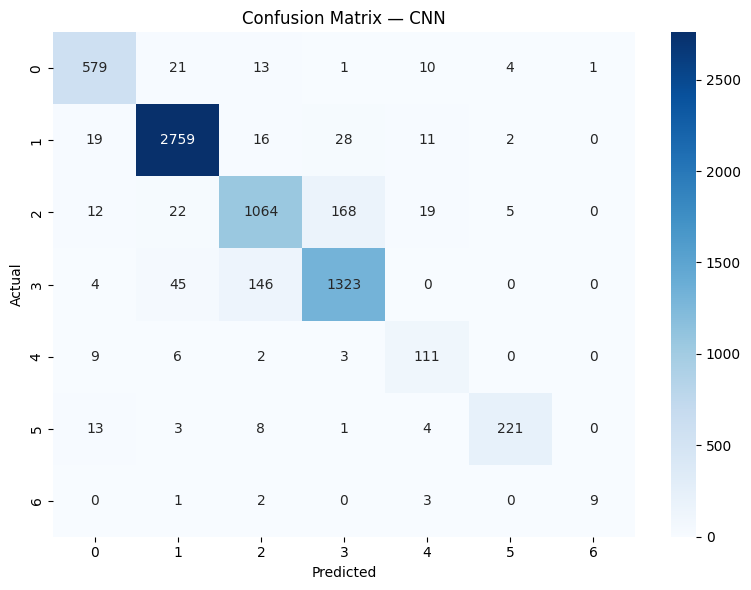

Macro AUC: 0.9865  95% CI [0.9798, 0.9908]
Saved → outputs/03_SameLabel/CNN_roc_curve.png


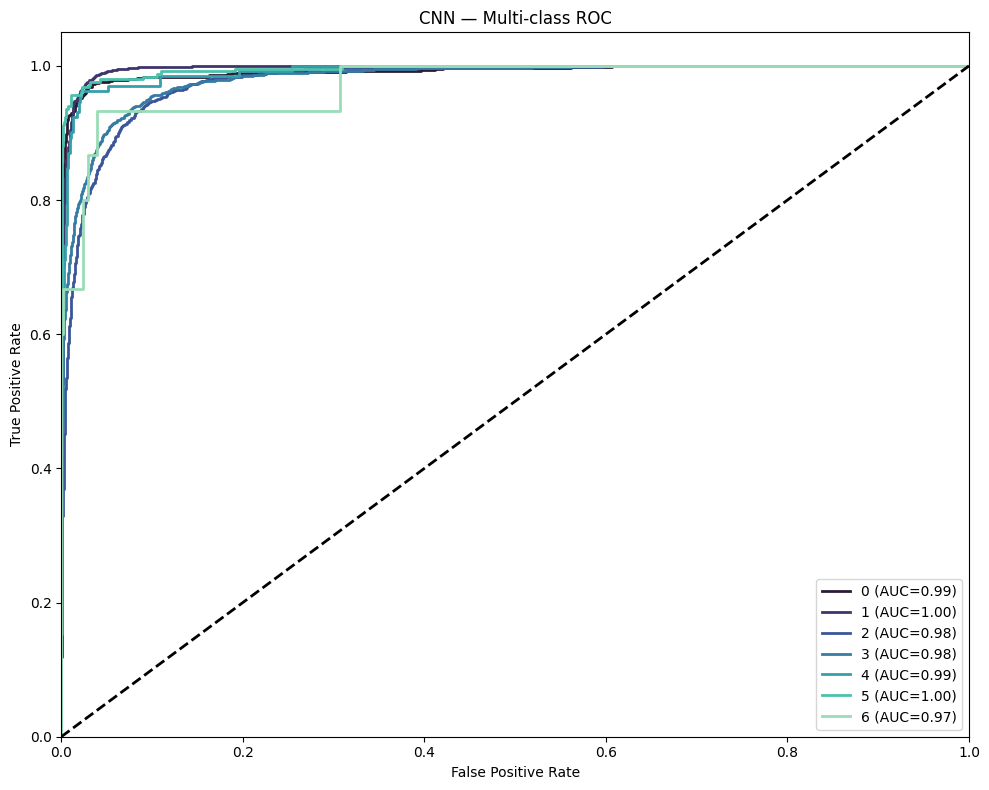

In [ ]:
cnn_preds, cnn_probs, y_true_cnn = evaluate_pytorch(
    best_cnn, test_loader_seq, label_encoder, "CNN", use_attention_mask=False
)

## 4.2 Transformer

### 4.2.1 Generic transformer train function

In [ ]:
def dropout_report(module):
    """Map every instantiated nn.Dropout to its probability.

    Reporting the full named map avoids guessing which layer matters: ALBERT's
    backbone dropout is 0.0 while its classifier dropout carries the sampled
    value, and the aspect head's dropout is separate from the encoder's.
    """
    report = {}
    for name, m in module.named_modules():
        if isinstance(m, nn.Dropout):
            report[name or "<root>"] = float(m.p)
    return report


def sampled_dropout_effective(module):
    """The dropout the sampled hyperparameter is meant to control.

    In AlbertForSequenceClassification the classifier dropout module is the
    top-level ``dropout`` (the backbone's own dropout is 0.0), so prefer the
    shallowest module whose name ends in "dropout"; fall back to the deepest
    encoder dropout only if no top-level one exists.
    """
    report = dropout_report(module)
    if not report:
        return None
    named = sorted(report.items(), key=lambda kv: (kv[0].count("."), len(kv[0])))
    for name, p in named:
        if "classifier" in name.lower():
            return p
    for name, p in named:
        if name.split(".")[-1].lower() == "dropout":
            return p
    return named[0][1]

def train_transformer(model, train_loader, val_loader,
                      lr=2e-5, max_epochs=6, patience=2):
    """Fine-tune a HuggingFace transformer with FP16, grad clip, OneCycleLR."""
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    total_steps = max_epochs * len(train_loader)
    scheduler = OneCycleLR(optimizer, max_lr=lr, total_steps=total_steps, pct_start=0.1)
    criterion = nn.CrossEntropyLoss(weight=class_weights_dl)
    scaler = GradScaler(enabled=USE_FP16)

    best_f1, best_state, no_improve = -1.0, None, 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda", enabled=USE_FP16):
                outputs = model(input_ids=ids, attention_mask=mask)
                logits = outputs.logits if hasattr(outputs, "logits") else outputs
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            losses.append(loss.item())

        # Validate
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
                mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
                with autocast("cuda", enabled=USE_FP16):
                    out = model(input_ids=ids, attention_mask=mask)
                logits = out.logits if hasattr(out, "logits") else out
                val_preds.extend(logits.float().argmax(dim=1).cpu().numpy())
                val_true.extend(batch["label"].numpy())

        val_f1 = f1_score(val_true, val_preds, average="weighted")
        print(f"  Epoch {epoch}/{max_epochs} | Loss={np.mean(losses):.4f} | Val F1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            raw = model._orig_mod if hasattr(model, "_orig_mod") else model
            best_state = {k: v.cpu().clone() for k, v in raw.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    raw = model._orig_mod if hasattr(model, "_orig_mod") else model
    if best_state:
        raw.load_state_dict(best_state)
    return best_f1, raw

### 4.2.2 ALBERT

#### Step 1: Data Preparation

In [ ]:
print("\nPre-tokenizing for ALBERT...")
albert_tokenizer = AutoTokenizer.from_pretrained("albert-base-v2")


def batch_tokenize(texts, tokenizer, max_len, batch_size=512):
    all_ids, all_masks = [], []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(
            texts[i:i+batch_size], max_length=max_len,
            truncation=True, padding="max_length", return_tensors="pt",
        )
        all_ids.append(enc["input_ids"])
        all_masks.append(enc["attention_mask"])
    return torch.cat(all_ids), torch.cat(all_masks)


# Use same text lists as DL
train_ids_albert, train_masks_albert = batch_tokenize(train_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
val_ids_albert, val_masks_albert     = batch_tokenize(val_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
test_ids_albert, test_masks_albert   = batch_tokenize(test_texts_dl, albert_tokenizer, MAX_TOKEN_LENGTH)
print(f"ALBERT tokens: train={train_ids_albert.shape}")


# ── Cached dataset for transformers ──────────────────────
class TransformerDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = torch.tensor(np.asarray(labels, dtype=np.int64))

    def __len__(self):
        return self.input_ids.shape[0]

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "label": self.labels[idx],
        }


_tf_loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2,
                     pin_memory=True, persistent_workers=True, prefetch_factor=4)

train_loader_albert = DataLoader(
    TransformerDataset(train_ids_albert, train_masks_albert, train_labels_dl),
    shuffle=True, **_tf_loader_kw)
val_loader_albert = DataLoader(
    TransformerDataset(val_ids_albert, val_masks_albert, val_labels_dl),
    shuffle=False, **_tf_loader_kw)
test_loader_albert = DataLoader(
    TransformerDataset(test_ids_albert, test_masks_albert, test_labels_dl),
    shuffle=False, **_tf_loader_kw)


Pre-tokenizing for ALBERT...


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

ALBERT tokens: train=torch.Size([19924, 200])


#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

if RETRAIN:
    set_seed()
    print("\nTuning ALBERT...")
    start = time.time()

    albert_param_space = {
        "lr": (np.log10(1e-5), np.log10(3e-5)),
        "epochs": (4, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_albert, best_params_albert, best_albert = -1.0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="ALBERT Random Search"):
        hp = {
            "lr": float(10 ** np.random.uniform(*albert_param_space["lr"])),
            "epochs": int(np.random.randint(*albert_param_space["epochs"])),
            "dropout": float(np.random.uniform(*albert_param_space["dropout"])),
        }

        model = AlbertForSequenceClassification.from_pretrained(
            "albert-base-v2", num_labels=NUM_CLASSES,
            classifier_dropout_prob=hp["dropout"],
        )
        hp["dropout_modules"] = dropout_report(model)
        hp["effective_dropout"] = sampled_dropout_effective(model)

        if TORCH_COMPILE_OK:
            model = torch.compile(model, mode="reduce-overhead")

        f1_val, model = train_transformer(
            model, train_loader_albert, val_loader_albert,
            lr=hp["lr"], max_epochs=hp["epochs"], patience=3,
        )

        if f1_val > best_f1_albert:
            best_f1_albert = f1_val
            best_params_albert = hp
            best_albert = model

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"ALBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_albert:.4f}")
    print(f"Best params: {best_params_albert}")
    with open(MODEL_PATHS["albert"]["params"], "w") as _f:
        json.dump(best_params_albert, _f, indent=2)
    print(f"Saved params -> {MODEL_PATHS['albert']['params']}")

    torch.save(best_albert.state_dict(), MODEL_PATHS["albert"]["model"])

    with open(MODEL_PATHS["albert"]["params"], "w") as _pf:

        json.dump(best_params_albert, _pf, indent=2)
else:
    print("Loading ALBERT from disk...")
    with open(MODEL_PATHS["albert"]["params"]) as _f:
        best_params_albert = json.load(_f)
    best_albert = AlbertForSequenceClassification.from_pretrained(
        "albert-base-v2", num_labels=NUM_CLASSES,
        classifier_dropout_prob=best_params_albert["dropout"],
    )
    best_albert.load_state_dict(torch.load(MODEL_PATHS["albert"]["model"], map_location=DEVICE))
    print(f"Loaded ALBERT from {MODEL_PATHS['albert']['model']}")


Tuning ALBERT...


ALBERT Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 47.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/9 | Loss=1.4645 | Val F1=0.8691
  Epoch 2/9 | Loss=0.4153 | Val F1=0.8958
  Epoch 3/9 | Loss=0.2331 | Val F1=0.9021
  Epoch 4/9 | Loss=0.1324 | Val F1=0.9320
  Epoch 5/9 | Loss=0.0838 | Val F1=0.9343
  Epoch 6/9 | Loss=0.0469 | Val F1=0.9391
  Epoch 7/9 | Loss=0.0212 | Val F1=0.9387
  Epoch 8/9 | Loss=0.0113 | Val F1=0.9402
  Epoch 9/9 | Loss=0.0080 | Val F1=0.9385


ALBERT Random Search: 100%|██████████| 10/10 [39:44<00:00, 238.41s/it]

ALBERT tuning: 2384.1s | Best F1=0.9402
Best params: {'lr': 2.9768448441450054e-05, 'epochs': 9, 'dropout': 0.2365358833708563, 'dropout_modules': {'albert.embeddings.dropout': 0.0, 'albert.encoder.albert_layer_groups.0.albert_layers.0.attention.attention_dropout': 0.0, 'albert.encoder.albert_layer_groups.0.albert_layers.0.attention.output_dropout': 0.0, 'albert.encoder.albert_layer_groups.0.albert_layers.0.dropout': 0.0, 'dropout': 0.2365358833708563}, 'effective_dropout': 0.2365358833708563}
Saved params -> outputs/03_SameLabel/best_albert_params.json


#### Step 3: Model Evaluation

Eval ALBERT: 100%|██████████| 53/53 [00:04<00:00, 11.88it/s]



Evaluation: ALBERT
                      precision    recall  f1-score   support

             Anxiety     0.9515    0.9666    0.9590       629
              Normal     0.9794    0.9901    0.9847      2835
          Depression     0.8781    0.8992    0.8885      1290
            Suicidal     0.9235    0.8906    0.9068      1518
              Stress     0.8824    0.8015    0.8400       131
             Bipolar     0.9677    0.9600    0.9639       250
Personality disorder     0.8182    0.6000    0.6923        15

            accuracy                         0.9420      6668
           macro avg     0.9144    0.8726    0.8907      6668
        weighted avg     0.9417    0.9420    0.9417      6668

Weighted F1: 0.9417  95% CI [0.9358, 0.9471]
Macro F1:    0.8907  95% CI [0.8509, 0.9183]
Saved → outputs/03_SameLabel/ALBERT_confusion_matrix.png


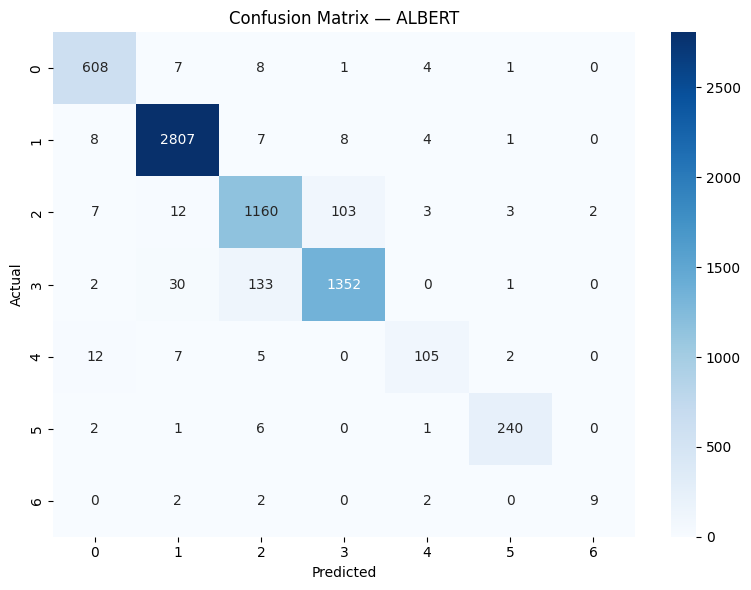

Macro AUC: 0.9922  95% CI [0.9886, 0.9949]
Saved → outputs/03_SameLabel/ALBERT_roc_curve.png


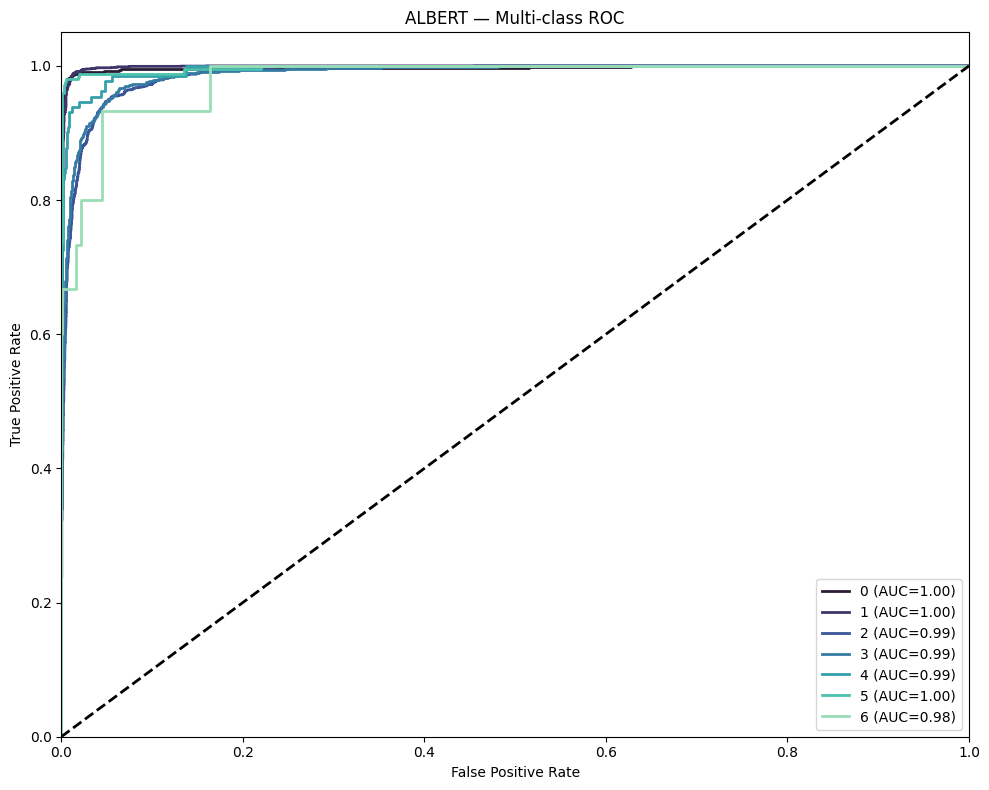

In [ ]:
albert_preds, albert_probs, y_true_albert = evaluate_pytorch(
    best_albert, test_loader_albert, label_encoder, "ALBERT", use_attention_mask=True
)

### 4.4.3 BioBERT Modeling

#### Step 1: Data Preparation

In [ ]:
print("\nPre-tokenizing for BioBERT...")
biobert_name = "dmis-lab/biobert-v1.1"
biobert_tokenizer = AutoTokenizer.from_pretrained(biobert_name)

train_ids_bio, train_masks_bio = batch_tokenize(train_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
val_ids_bio, val_masks_bio     = batch_tokenize(val_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
test_ids_bio, test_masks_bio   = batch_tokenize(test_texts_dl, biobert_tokenizer, MAX_TOKEN_LENGTH)
print(f"BioBERT tokens: train={train_ids_bio.shape}")

train_loader_biobert = DataLoader(
    TransformerDataset(train_ids_bio, train_masks_bio, train_labels_dl),
    shuffle=True, **_tf_loader_kw)
val_loader_biobert = DataLoader(
    TransformerDataset(val_ids_bio, val_masks_bio, val_labels_dl),
    shuffle=False, **_tf_loader_kw)
test_loader_biobert = DataLoader(
    TransformerDataset(test_ids_bio, test_masks_bio, test_labels_dl),
    shuffle=False, **_tf_loader_kw)


Pre-tokenizing for BioBERT...


config.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

BioBERT tokens: train=torch.Size([19924, 200])


#### Step 2: Hyperparameter Tuning

In [ ]:
RETRAIN = True

if RETRAIN:
    set_seed()
    print("\nTuning BioBERT...")
    start = time.time()

    biobert_param_space = {
        "lr": (np.log10(1e-5), np.log10(3e-5)),
        "epochs": (4, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_biobert, best_params_biobert, best_biobert = -1.0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="BioBERT Random Search"):
        hp = {
            "lr": float(10 ** np.random.uniform(*biobert_param_space["lr"])),
            "epochs": int(np.random.randint(*biobert_param_space["epochs"])),
            "dropout": float(np.random.uniform(*biobert_param_space["dropout"])),
        }

        biobert_config = AutoConfig.from_pretrained(
            biobert_name, num_labels=NUM_CLASSES,
        )
        # Dropout must be set on the config BEFORE instantiation, otherwise the
        # already-constructed nn.Dropout modules keep the pretrained default and
        # the sampled value never takes effect (the R0 behaviour).
        biobert_config.hidden_dropout_prob = hp["dropout"]
        biobert_config.attention_probs_dropout_prob = hp["dropout"]

        model = AutoModelForSequenceClassification.from_pretrained(
            biobert_name, config=biobert_config,
        )
        hp["dropout_modules"] = dropout_report(model)
        hp["effective_dropout"] = sampled_dropout_effective(model)

        if TORCH_COMPILE_OK:
            model = torch.compile(model, mode="reduce-overhead")

        f1_val, model = train_transformer(
            model, train_loader_biobert, val_loader_biobert,
            lr=hp["lr"], max_epochs=hp["epochs"], patience=3,
        )

        if f1_val > best_f1_biobert:
            best_f1_biobert = f1_val
            best_params_biobert = hp
            best_biobert = model

        del model
        gc.collect()
        torch.cuda.empty_cache()

    print(f"BioBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_biobert:.4f}")
    print(f"Best params: {best_params_biobert}")
    with open(MODEL_PATHS["biobert"]["params"], "w") as _f:
        json.dump(best_params_biobert, _f, indent=2)
    print(f"Saved params -> {MODEL_PATHS['biobert']['params']}")

    torch.save(best_biobert.state_dict(), MODEL_PATHS["biobert"]["model"])

    with open(MODEL_PATHS["biobert"]["params"], "w") as _pf:

        json.dump(best_params_biobert, _pf, indent=2)
else:
    print("Loading BioBERT from disk...")
    with open(MODEL_PATHS["biobert"]["params"]) as _f:
        best_params_biobert = json.load(_f)
    biobert_config = AutoConfig.from_pretrained(biobert_name, num_labels=NUM_CLASSES)
    biobert_config.hidden_dropout_prob = best_params_biobert["dropout"]
    biobert_config.attention_probs_dropout_prob = best_params_biobert["dropout"]
    best_biobert = AutoModelForSequenceClassification.from_pretrained(
        biobert_name, config=biobert_config,
    )
    best_biobert.load_state_dict(torch.load(MODEL_PATHS["biobert"]["model"], map_location=DEVICE))
    print(f"Loaded BioBERT from {MODEL_PATHS['biobert']['model']}")



Tuning BioBERT...


BioBERT Random Search:   0%|          | 0/10 [00:00<?, ?it/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  433MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-v1.1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/9 | Loss=1.6056 | Val F1=0.7625
  Epoch 2/9 | Loss=0.5449 | Val F1=0.8802
  Epoch 3/9 | Loss=0.3240 | Val F1=0.8931
  Epoch 4/9 | Loss=0.2079 | Val F1=0.9127
  Epoch 5/9 | Loss=0.1460 | Val F1=0.9191
  Epoch 6/9 | Loss=0.1073 | Val F1=0.9292
  Epoch 7/9 | Loss=0.0925 | Val F1=0.9244
  Epoch 8/9 | Loss=0.0761 | Val F1=0.9267
  Epoch 9/9 | Loss=0.0753 | Val F1=0.9235
  Early stopping at epoch 9.


BioBERT Random Search: 100%|██████████| 10/10 [29:33<00:00, 177.38s/it]


BioBERT tuning: 1773.8s | Best F1=0.9292
Best params: {'lr': 2.9768448441450054e-05, 'epochs': 9, 'dropout': 0.2365358833708563, 'dropout_modules': {'bert.embeddings.dropout': 0.2365358833708563, 'bert.encoder.layer.0.attention.self.dropout': 0.2365358833708563, 'bert.encoder.layer.0.attention.output.dropout': 0.2365358833708563, 'bert.encoder.layer.0.output.dropout': 0.2365358833708563, 'bert.encoder.layer.1.attention.self.dropout': 0.2365358833708563, 'bert.encoder.layer.1.attention.output.dropout': 0.2365358833708563, 'bert.encoder.layer.1.output.dropout': 0.2365358833708563, 'bert.encoder.layer.2.attention.self.dropout': 0.2365358833708563, 'bert.encoder.layer.2.attention.output.dropout': 0.2365358833708563, 'bert.encoder.layer.2.output.dropout': 0.2365358833708563, 'bert.encoder.layer.3.attention.self.dropout': 0.2365358833708563, 'bert.encoder.layer.3.attention.output.dropout': 0.2365358833708563, 'bert.encoder.layer.3.output.dropout': 0.2365358833708563, 'bert.encoder.layer.4.at

#### Step 3: Model Evaluation

Eval BioBERT: 100%|██████████| 53/53 [00:02<00:00, 23.16it/s]



Evaluation: BioBERT
                      precision    recall  f1-score   support

             Anxiety     0.9311    0.9666    0.9485       629
              Normal     0.9867    0.9672    0.9768      2835
          Depression     0.8701    0.8674    0.8688      1290
            Suicidal     0.8876    0.8999    0.8937      1518
              Stress     0.8308    0.8244    0.8276       131
             Bipolar     0.9242    0.9760    0.9494       250
Personality disorder     0.6471    0.7333    0.6875        15

            accuracy                         0.9295      6668
           macro avg     0.8682    0.8907    0.8789      6668
        weighted avg     0.9302    0.9295    0.9297      6668

Weighted F1: 0.9297  95% CI [0.9237, 0.9361]
Macro F1:    0.8789  95% CI [0.8469, 0.9047]
Saved → outputs/03_SameLabel/BioBERT_confusion_matrix.png


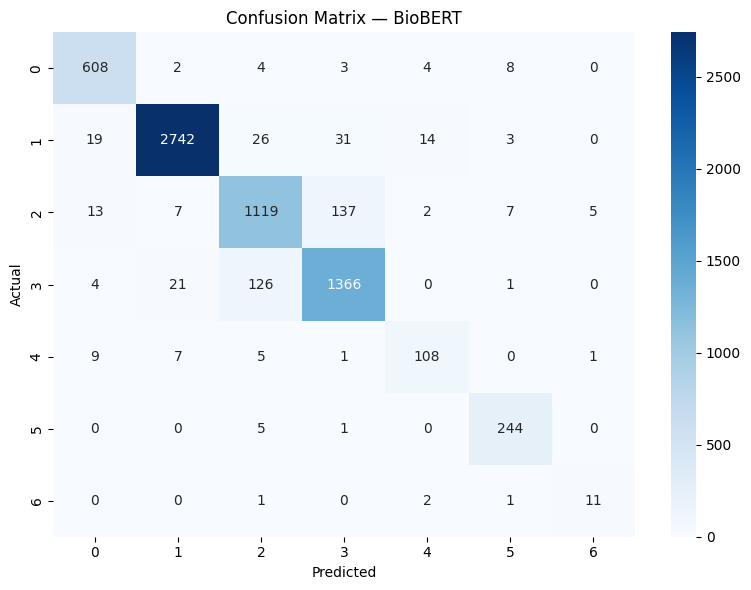

Macro AUC: 0.9931  95% CI [0.9916, 0.9944]
Saved → outputs/03_SameLabel/BioBERT_roc_curve.png


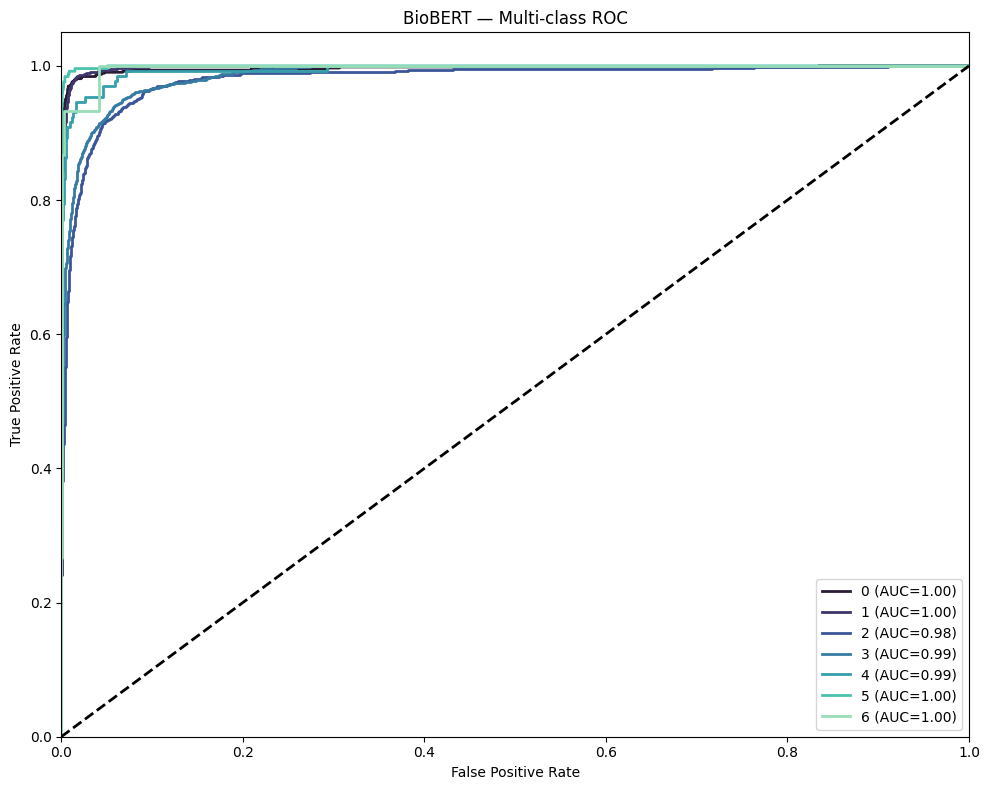

In [ ]:
biobert_preds, biobert_probs, y_true_biobert = evaluate_pytorch(
    best_biobert, test_loader_biobert, label_encoder, "BioBERT", use_attention_mask=True
)

## 4.3 Save Predictions for DL models

In [ ]:
print("\nSaving DL predictions...")

# Verify all DL models evaluated on same test set
assert np.array_equal(y_true_gru, y_true_cnn)
assert np.array_equal(y_true_gru, y_true_albert)
assert np.array_equal(y_true_gru, y_true_biobert)
y_true_dl = y_true_gru

true_names = label_encoder.inverse_transform(y_true_dl)

if "id" in df_test_dl.columns:
    df_pred_dl = df_test_dl[["id", TEXT_COLUMN, LABEL_COLUMN_ENCODED]].copy()
else:
    df_pred_dl = df_test_dl[[TEXT_COLUMN, LABEL_COLUMN_ENCODED]].copy()
    df_pred_dl.insert(0, "id", df_test_dl.index)

df_pred_dl = df_pred_dl.rename(columns={TEXT_COLUMN: "text", LABEL_COLUMN_ENCODED: "true_label_id"})
df_pred_dl["true_label"] = true_names

for name, preds, probs in [
    ("gru", gru_preds, gru_probs),
    ("cnn", cnn_preds, cnn_probs),
    ("albert", albert_preds, albert_probs),
    ("biobert", biobert_preds, biobert_probs),
]:
    df_pred_dl[f"{name}_pred_id"] = preds
    df_pred_dl[f"{name}_pred"] = label_encoder.inverse_transform(preds)
    for i, cls in enumerate(label_encoder.classes_):
        df_pred_dl[f"{name}_prob_{cls}"] = probs[:, i]

dl_pred_path = OUTPUT_PATH / "dl_models_predictions.csv"
df_pred_dl.to_csv(dl_pred_path, index=False)
print(f"Saved DL predictions → {dl_pred_path}")


Saving DL predictions...
Saved DL predictions → outputs/03_SameLabel/dl_models_predictions.csv


# 5. Model Comparison

In [34]:
print("\n" + "="*60)
print("MODEL COMPARISON — McNemar Pairwise Tests")
print("="*60)

# Load both prediction files
df_ml_pred = pd.read_csv(OUTPUT_PATH / "ml_models_predictions.csv")
df_dl_pred = pd.read_csv(OUTPUT_PATH / "dl_models_predictions.csv")

df_merged = pd.merge(df_ml_pred, df_dl_pred, on=["id", "true_label", "true_label_id"],
                     suffixes=("_ml", "_dl"))
print(f"Merged: {df_merged.shape[0]} rows")

y_true_all = df_merged["true_label_id"].values

# Build prediction dict
model_preds_all = {
    "LR":      label_encoder.transform(df_merged["lr_pred"].values),
    "SVM":     label_encoder.transform(df_merged["svm_pred"].values),  # <-- add this
    "RF":      label_encoder.transform(df_merged["rf_pred"].values),
    "LGBM":    label_encoder.transform(df_merged["lgbm_pred"].values),
    "GRU":     df_merged["gru_pred_id"].values,
    "CNN":     df_merged["cnn_pred_id"].values,
    "ALBERT":  df_merged["albert_pred_id"].values,
    "BioBERT": df_merged["biobert_pred_id"].values,
}

# Verify lengths
for name, arr in model_preds_all.items():
    assert len(arr) == len(y_true_all), f"{name} length mismatch"


def mcnemar_pairwise(y_true, model_preds, method="bonferroni"):
    y_true = np.asarray(y_true)
    names = list(model_preds.keys())
    results = []

    for m1, m2 in combinations(names, 2):
        y1, y2 = np.asarray(model_preds[m1]), np.asarray(model_preds[m2])
        c1 = (y1 == y_true)
        c2 = (y2 == y_true)

        a = np.sum(c1 & c2)
        b = np.sum(c1 & ~c2)
        c = np.sum(~c1 & c2)
        d = np.sum(~c1 & ~c2)

        res = mcnemar(np.array([[a, b], [c, d]]), exact=False, correction=True)
        p = res.pvalue

        if p >= 0.05:
            winner = "Inconclusive"
        elif b > c:
            winner = f"{m1} > {m2}"
        elif c > b:
            winner = f"{m2} > {m1}"
        else:
            winner = "Tie"

        results.append({
            "Model_1": m1, "Model_2": m2,
            "both_correct": a, "m1_only": b, "m2_only": c, "both_wrong": d,
            "statistic": res.statistic, "p_raw": p, "winner_raw": winner,
        })

    raw_p = [r["p_raw"] for r in results]
    _, corrected_p, _, _ = multipletests(raw_p, method=method)

    for i, pc in enumerate(corrected_p):
        results[i]["p_corrected"] = pc
        results[i]["significant"] = "Yes" if pc < 0.05 else "No"

    df_res = pd.DataFrame(results)
    print(f"\nPairwise McNemar Tests (corrected: {method}):")
    print(df_res.to_string(index=False))
    return df_res


df_mcnemar = mcnemar_pairwise(y_true_all, model_preds_all)

# Save
mcnemar_path = OUTPUT_PATH / "mcnemar_results.csv"
df_mcnemar.to_csv(mcnemar_path, index=False)
print(f"\nSaved McNemar results → {mcnemar_path}")

print("\n✓ Pipeline complete.")


MODEL COMPARISON — McNemar Pairwise Tests
Merged: 6668 rows

Pairwise McNemar Tests (corrected: bonferroni):
Model_1 Model_2  both_correct  m1_only  m2_only  both_wrong  statistic        p_raw       winner_raw  p_corrected significant
     LR     SVM          5930      123      123         492   0.004065 9.491632e-01     Inconclusive 1.000000e+00          No
     LR      RF          5586      467      245         370  68.596910 1.207932e-16          LR > RF 3.382210e-15         Yes
     LR    LGBM          5838      215      272         343   6.439425 1.116148e-02        LGBM > LR 3.125213e-01          No
     LR     GRU          5561      492      316         299  37.902228 7.438026e-10         LR > GRU 2.082647e-08         Yes
     LR     CNN          5735      318      331         284   0.221880 6.376113e-01     Inconclusive 1.000000e+00          No
     LR  ALBERT          5856      197      425         190  82.844051 8.878905e-20      ALBERT > LR 2.486093e-18         Yes
     LR 